## **I. Préparation des données**

## 1. Chargement des fichiers

In [2]:
from google.colab import files
uploaded = files.upload()

Saving customers.csv to customers.csv
Saving products.csv to products.csv
Saving Transactions.csv to Transactions.csv


In [3]:
# Chargement des bibliothèques de base pour cette analyse
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

In [4]:
# Lecture de fichiers
df_customers = pd.read_csv('customers.csv', sep=';')
df_products = pd.read_csv('products.csv', sep=';')
df_transactions = pd.read_csv('Transactions.csv', sep=';')

/tmp/ipython-input-1462025107.py:4: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv('Transactions.csv', sep=';')


## 2. Inspection initiale des fichiers sources

In [5]:
# Affichage des premières lignes des dataframes
print(df_customers.head()) #colonnes : client_id, sex, birth
print(df_products.head()) #colonnes : id_prod, price, categ
print(df_transactions.head()) #colonnes : id_prod, date session_id, client_id

  client_id sex  birth
0    c_4410   f   1967
1    c_7839   f   1975
2    c_1699   f   1984
3    c_5961   f   1962
4    c_5320   m   1943
  id_prod  price  categ
0  0_1421  19.99      0
1  0_1368   5.13      0
2   0_731  17.99      0
3   1_587   4.99      1
4  0_1507   3.99      0
  id_prod                        date session_id client_id
0  0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1  0_1390  2021-03-01 00:02:26.047414        s_2     c_664
2  0_1352  2021-03-01 00:02:38.311413        s_3     c_580
3  0_1458  2021-03-01 00:04:54.559692        s_4    c_7912
4  0_1358  2021-03-01 00:05:18.801198        s_5    c_2033


Sur la base des résultats de l'aperçu des données, les clés sont définies :

1.   **id_prod** pour lier les tables de **produits** et de **transactions**
2.   **client_id** pour lier les tables de **clients** et de **transactions**

In [6]:
# dimensions du tableau
print("📐 Dimensions:")
print(f"customers: {df_customers.shape}")
print(f"products: {df_products.shape}")
print(f"transactions: {df_transactions.shape}")

📐 Dimensions:
customers: (8621, 3)
products: (3286, 3)
transactions: (1048575, 4)


In [7]:
#Afficher types de données
df_customers.info()
df_products.info()
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session

La vérification du type de données a montré
que les types de données des colonnes clés
correspondent dans les tables qui seront jointes

In [8]:
#Vérifier si client_id contient des valeurs vides dans df_customers
print("Valeurs vides dans df_customers['client_id']:", df_customers['client_id'].isnull().sum())

#Vérifier si client_id contient des doublons dans df_customers
print("Doublons dans df_customers['client_id']:", df_customers['client_id'].duplicated().sum())

#Vérifier si id_prod contient des valeurs vides dans df_products
print("Valeurs vides dans df_products['id_prod']:", df_products['id_prod'].isnull().sum())

#Vérifier si id_prod contient des doublons dans df_products
print("Doublons dans df_products['id_prod']:", df_products['id_prod'].duplicated().sum())

Valeurs vides dans df_customers['client_id']: 0
Doublons dans df_customers['client_id']: 0
Valeurs vides dans df_products['id_prod']: 0
Doublons dans df_products['id_prod']: 0


In [9]:
#vérification des clés pour une sélection de jointure optimale product et transactions

# Jointure temporaire pour vérifier pertes éventuelles
check_merge_prod = df_transactions.merge(df_products, on='id_prod', how='outer', indicator=True)

# Afficher le résultat
print(check_merge_prod['_merge'].value_counts())

_merge
both          687534
left_only     361041
right_only        21
Name: count, dtype: int64


In [10]:
#vérification des clés pour une sélection de jointure optimale customer et transactions

# Jointure temporaire pour vérifier pertes éventuelles
check_merge_cust = df_transactions.merge(df_customers, on='client_id', how='outer', indicator=True)

# Afficher le résultat
print(check_merge_cust['_merge'].value_counts())

_merge
both          687534
left_only     361041
right_only        21
Name: count, dtype: int64


**transactions + products (по id_prod):**
*   both: 687 534 lignes - correctement appariées
*   left_only: 361 041 lignes – présentes dans les transactions, mais pas dans les produits
*   right_only: 21 lignes — produits sans transactions (OK)

**transactions + customers (по client_id):**
*   same results - les mêmes 687 534 lignes correspondant aux clients
*   également 361041 lignes sont restées sans correspondance

Il y avait de nombreuses lignes en double dans les transactions qui n'ont pas trouvé de correspondance et ont pu être supprimées lors de la fusion.

## 3. Jointure des donnes

In [11]:
# Fusionner les tables : transactions + produits
df_merge = df_transactions.merge(df_products,
                                 on='id_prod',                                  # Fusionner en utilisant la clé produit
                                 how='inner')                                   # Utiliser une jointure interne (ne conserver que les correspondances)

# Fusionner avec la table des clients
df_merge = df_merge.merge(df_customers,
                          on='client_id',                                       # Fusionner en utilisant la clé client
                          how='inner')                                          # Utiliser une jointure interne (ne conserver que les correspondances)

# Vérification finale du DataFrame fusionné
print(df_merge.head())                                                          # Afficher les premières lignes pour contrôler le résultat
print("Dimensions:", df_merge.shape)                                            # Afficher le nombre de lignes et de colonnes (shape)
print("Colonnes:", df_merge.columns)                                            # Afficher la liste des noms de colonnes


  id_prod                        date session_id client_id  price  categ sex  \
0  0_1259  2021-03-01 00:01:07.843138        s_1     c_329  11.99      0   f   
1  0_1390  2021-03-01 00:02:26.047414        s_2     c_664  19.37      0   m   
2  0_1352  2021-03-01 00:02:38.311413        s_3     c_580   4.50      0   m   
3  0_1458  2021-03-01 00:04:54.559692        s_4    c_7912   6.55      0   f   
4  0_1358  2021-03-01 00:05:18.801198        s_5    c_2033  16.49      0   f   

   birth  
0   1967  
1   1960  
2   1988  
3   1989  
4   1956  
Dimensions: (687534, 8)
Colonnes: Index(['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex',
       'birth'],
      dtype='object')


In [12]:
# vérifier les doublons complets (absolus) des lignes dans df_merge
nb_full_duplicates = df_merge.duplicated().sum()
print("🔁 Nombre de doublons exacts (lignes entièrement identiques):", nb_full_duplicates)

🔁 Nombre de doublons exacts (lignes entièrement identiques): 0


## 4. Transformation des données pour analyse

In [13]:
# Diviser une colonne de date en composants de temps

# Vérifier le type de données dans la colonne de date
df_merge['date'] = pd.to_datetime(df_merge['date'])                             # Convertir la colonne 'date' au format datetime si ce n’est pas déjà le cas

# Créer de nouvelles colonnes (sans supprimer l'original)
df_merge['année'] = df_merge['date'].dt.year                                    # Extraire l’année de la date
df_merge['trimestre'] = df_merge['date'].dt.quarter                             # Extraire le trimestre de la date
df_merge['mois'] = df_merge['date'].dt.month                                    # Extraire le mois de la date
df_merge['jour'] = df_merge['date'].dt.day                                      # Extraire le jour du mois
df_merge['heure'] = df_merge['date'].dt.hour                                    # Extraire l’heure

# Vérification des colonnes créées
print(df_merge[['date', 'année', 'trimestre', 'mois', 'jour', 'heure']].head()) # Afficher les premières lignes pour contrôle visuel

# Vérification des types de données des colonnes créées
cols_temporelles = ['année', 'trimestre', 'mois', 'jour', 'heure']              # Lister les nouvelles colonnes temporelles
df_merge[cols_temporelles].dtypes                                               # Afficher les types de données de ces colonnes


                        date  année  trimestre  mois  jour  heure
0 2021-03-01 00:01:07.843138   2021          1     3     1      0
1 2021-03-01 00:02:26.047414   2021          1     3     1      0
2 2021-03-01 00:02:38.311413   2021          1     3     1      0
3 2021-03-01 00:04:54.559692   2021          1     3     1      0
4 2021-03-01 00:05:18.801198   2021          1     3     1      0


,0
année,int32
trimestre,int32
mois,int32
jour,int32
heure,int32


In [14]:
# créer une colonne d'âge
df_merge['age'] = 2025 - df_merge['birth']

In [15]:
# aperçu final
df_merge.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth,année,trimestre,mois,jour,heure,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,2021,1,3,1,0,58
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,2021,1,3,1,0,65
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,2021,1,3,1,0,37
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,2021,1,3,1,0,36
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,2021,1,3,1,0,69


Résultat final est un DataFrame pour l'analyse contenant : ***id_prod, date,	session_id, client_id, price,	categ,	sex,	birth,	année,	trimestre,	mois,	jour,	heure, age***

## 5. Trouver des clients B2B

In [16]:
# trouver les clients avec le chiffre d'affaires le plus élevé

# Grouper par client et sommer le CA (chiffre d'affaires)
ca_par_client = df_merge.groupby('client_id')['price'].sum()

# Trier par ordre décroissant pour avoir les clients avec le plus grand CA
ca_par_client = ca_par_client.sort_values(ascending=False)

# Afficher les 20 premiers clients avec le plus de CA
print(ca_par_client.head(20))

client_id
c_1609    326039.89
c_4958    290227.03
c_6714    153918.60
c_3454    114110.57
c_1570      5285.82
c_3263      5276.87
c_2140      5260.18
c_2899      5214.05
c_7319      5155.77
c_7959      5135.75
c_1422      5131.36
c_7421      5097.18
c_8026      5082.58
c_2505      5059.35
c_1876      5026.60
c_4491      5025.05
c_5263      5006.85
c_2595      4959.66
c_8392      4934.01
c_880       4897.19
Name: price, dtype: float64


In [17]:
#créer un dataframe pour les clients b2b

# Liste des clients B2B
clients_b2b = ['c_1609', 'c_4958', 'c_6714', 'c_3454']

# Filtrer les lignes où client_id correspond à l'un des B2B
df_b2b = df_merge[df_merge['client_id'].isin(clients_b2b)]

# Vérifier le résultat
print(df_b2b.head())

   id_prod                       date session_id client_id  price  categ sex  \
6   0_1304 2021-03-01 00:07:04.371179        s_7    c_1609   5.86      0   m   
13  0_1159 2021-03-01 00:11:57.832228        s_7    c_1609   7.99      0   m   
50  0_1431 2021-03-01 01:08:49.803921       s_33    c_3454  10.99      0   m   
78  0_1425 2021-03-01 01:56:41.944044       s_46    c_1609  12.99      0   m   
88  0_1469 2021-03-01 02:12:21.294004       s_53    c_1609  14.99      0   m   

    birth  année  trimestre  mois  jour  heure  age  
6    1980   2021          1     3     1      0   45  
13   1980   2021          1     3     1      0   45  
50   1969   2021          1     3     1      1   56  
78   1980   2021          1     3     1      1   45  
88   1980   2021          1     3     1      2   45  


In [18]:
# ne laisser que les clients b2c dans le dataframe principal

# Suppression des lignes avec ces client_id de df_merge
df_merge = df_merge[~df_merge['client_id'].isin(clients_b2b)]

# Vérifier le résultat
ca_par_client = df_merge.groupby('client_id')['price'].sum()
ca_par_client = ca_par_client.sort_values(ascending=False)
print(ca_par_client.head(20))

client_id
c_1570    5285.82
c_3263    5276.87
c_2140    5260.18
c_2899    5214.05
c_7319    5155.77
c_7959    5135.75
c_1422    5131.36
c_7421    5097.18
c_8026    5082.58
c_2505    5059.35
c_1876    5026.60
c_4491    5025.05
c_5263    5006.85
c_2595    4959.66
c_8392    4934.01
c_880     4897.19
c_8510    4888.16
c_1636    4883.56
c_2077    4848.06
c_4840    4826.51
Name: price, dtype: float64


## **II. Analyse univariée**

## 1. Price

In [19]:
# Statistiques de base
print("Statistiques pour 'price':")                                             # Afficher un titre pour la section descriptive du prix
print(df_merge['price'].describe())                                             # Afficher les statistiques de base pour la variable 'price'

# Quartiles
q1 = df_merge['price'].quantile(0.25)                                           # Calculer le premier quartile (Q1) du prix
q3 = df_merge['price'].quantile(0.75)                                           # Calculer le troisième quartile (Q3) du prix
iqr = q3 - q1                                                                   # Calculer l’intervalle interquartile (IQR)

# Limites pour détection des valeurs aberrantes
borne_inf = q1 - 1.5 * iqr                                                      # Définir la borne inférieure des valeurs extrêmes
borne_sup = q3 + 1.5 * iqr                                                      # Définir la borne supérieure des valeurs extrêmes

print(f"\nIQR: {iqr:.2f}")                                                      # Afficher l’IQR avec deux décimales
print(f"Borne inférieure: {borne_inf:.2f}")                                     # Afficher la borne inférieure
print(f"Borne supérieure: {borne_sup:.2f}")                                     # Afficher la borne supérieure

# Nombre de valeurs aberrantes
aberrants = df_merge[(df_merge['price'] < borne_inf) | (df_merge['price'] > borne_sup)]  # Identifier les prix hors limites
print(f"Nombre de valeurs aberrantes: {aberrants.shape[0]}")                    # Afficher le nombre de valeurs considérées comme aberrantes


Statistiques pour 'price':
count    640734.000000
mean         17.391565
std          18.003423
min           0.620000
25%           8.990000
50%          13.990000
75%          19.040000
max         300.000000
Name: price, dtype: float64

IQR: 10.05
Borne inférieure: -6.08
Borne supérieure: 34.11
Nombre de valeurs aberrantes: 38814


* **Médiane** (13,99 €) < **moyenne** (17,49 €) → certains articles très chers font grimper la moyenne.

* **Maximum** = 300 € — probablement des livres de collection ou rares. Ce n'est pas une erreur, mais vous pouvez vérifier.

* 42 800 valeurs supérieures à 34,21 € (**selon la règle du boxplot**) sont des valeurs aberrantes potentielles, mais seulement 6,2 % d'entre elles sont tout à fait acceptables pour une boutique en ligne proposant des produits haut de gamme.

* **IQR** est la « plage normale » de valeurs où se concentrent les 50 % médians de mes observations.

* **Borne inférieure:** -6.14 (mais les prix négatifs ne sont pas possibles).

* **Borne supérieure:** 34.21 (tous les prix supérieurs à 34,21 € sont considérés comme des valeurs aberrantes potentielles par la méthode du boxplot).

## 2. Age

In [20]:
# Statistiques descriptives
print("Statistiques pour 'age':")                                               # Afficher le titre pour la section des statistiques
print(df_merge['age'].describe())                                               # Afficher les statistiques descriptives classiques pour la variable 'age'

# Quartiles
q1 = df_merge['age'].quantile(0.25)                                             # Calculer le premier quartile (Q1)
q3 = df_merge['age'].quantile(0.75)                                             # Calculer le troisième quartile (Q3)
iqr = q3 - q1                                                                   # Calculer l'intervalle interquartile (IQR = Q3 - Q1)

# Limites pour détecter les valeurs aberrantes (selon 1.5*IQR)
borne_inf = q1 - 1.5 * iqr                                                      # Définir la borne inférieure pour les valeurs extrêmes
borne_sup = q3 + 1.5 * iqr                                                      # Définir la borne supérieure pour les valeurs extrêmes

print(f"\nIQR: {iqr:.2f}")                                                      # Afficher l'IQR avec deux décimales
print(f"Borne inférieure (valeurs extrêmes): {borne_inf:.2f}")                  # Afficher la borne inférieure
print(f"Borne supérieure (valeurs extrêmes): {borne_sup:.2f}")                  # Afficher la borne supérieure

# Détection des valeurs aberrantes
outliers_age = df_merge[(df_merge['age'] < borne_inf) | (df_merge['age'] > borne_sup)]  # Identifier les âges en dehors des bornes
print(f"Nombre de valeurs aberrantes (age): {outliers_age.shape[0]}")           # Afficher le nombre de valeurs considérées comme aberrantes


Statistiques pour 'age':
count    640734.000000
mean         47.207976
std          13.879682
min          21.000000
25%          38.000000
50%          46.000000
75%          54.000000
max          96.000000
Name: age, dtype: float64

IQR: 16.00
Borne inférieure (valeurs extrêmes): 14.00
Borne supérieure (valeurs extrêmes): 78.00
Nombre de valeurs aberrantes (age): 17877


🔹 Segment d’âge clé
L’âge médian des clients est de 45 ans, et 50 % d’entre eux se situent dans la tranche 38–55 ans. Cela indique que la clientèle principale est composée d’acheteurs adultes d’âge moyen.

🔹 Acheteurs plus âgés
L’âge maximum observé est de 96 ans, et un quart des clients ont plus de 55 ans. Par conséquent, la génération senior reste très active dans l’achat, ce qui implique de prendre en compte ses besoins (accessibilité, confiance, présentation des vitrines).

🔹 Valeurs aberrantes liées à l’âge
14 036 valeurs anormales ont été relevées pour l’âge (hors intervalle 12,5–72,5 ans). Cela peut résulter d’erreurs lors de l’enregistrement ou de données incorrectes, ce qui nécessite un nettoyage pour un ciblage plus précis.

🔹 La jeunesse ne domine pas
Seulement 25 % des clients ont moins de 38 ans — ce qui signifie que les jeunes ne constituent pas le groupe principal de clientèle, et que le marketing qui leur est dédié risque d’être moins efficace.

In [21]:
# Remplacez l'âge exact par les catégories d'âge pour faciliter l'analyse

# Créer des conditions pour chaque catégorie (tranche d'âge)
conditions = [
    df_merge['age'] <= 29,                                                      # Sélectionner les clients âgés de 29 ans ou moins
    df_merge['age'].between(30, 44),                                            # Sélectionner les clients âgés entre 30 et 44 ans inclus
    df_merge['age'].between(45, 59),                                            # Sélectionner les clients âgés entre 45 et 59 ans inclus
    df_merge['age'].between(60, 74),                                            # Sélectionner les clients âgés entre 60 et 74 ans inclus
    df_merge['age'] >= 75                                                       # Sélectionner les clients âgés de 75 ans ou plus
]

# Définir les noms des groupes correspondant aux conditions
categories = [
    '< 30 ans',                                                                 # Nommer la première tranche d’âge
    '30 - 44 ans',                                                              # Nommer la deuxième tranche d’âge
    '45 - 59 ans',                                                              # Nommer la troisième tranche d’âge
    '60 - 74 ans',                                                              # Nommer la quatrième tranche d’âge
    '>= 75 ans'                                                                 # Nommer la dernière tranche d’âge
]

# Créer une сolonne pour catégoriser les âges
df_merge['cat_age'] = np.select(conditions, categories, default='Unknown')      # Appliquer les conditions et affecter les catégories

In [22]:
# aperçu final
df_merge.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth,année,trimestre,mois,jour,heure,age,cat_age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,2021,1,3,1,0,58,45 - 59 ans
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,2021,1,3,1,0,65,60 - 74 ans
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,2021,1,3,1,0,37,30 - 44 ans
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,2021,1,3,1,0,36,30 - 44 ans
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,2021,1,3,1,0,69,60 - 74 ans


## **III. Calcul des indicateurs (Brief de l’analyse)**

## 1. Chiffre d'affaires (CA)

In [23]:
# CA b2b
ca_b2b = df_b2b['price'].sum()
print(f"CA B2B : {ca_b2b:,.2f} €")

# CA b2c
ca_b2c = df_merge['price'].sum()
print(f"CA B2C : {ca_b2c:,.2f} €")

# CA total
ca_total = ca_b2b + ca_b2c
print(f"CA total : {ca_total:,.2f} €")

CA B2B : 884,296.09 €
CA B2C : 11,143,367.01 €
CA total : 12,027,663.10 €


In [24]:
# Évolution du CA dans le temps - regroupement de données
ca_par_annee = df_merge.groupby('année')['price'].sum()                         # CA par année
ca_par_trimestre = df_merge.groupby(['année', 'trimestre'])['price'].sum()      # CA par trimestre
ca_par_mois = df_merge.groupby(['année', 'mois'])['price'].sum()                # CA par mois (année + mois groupé)

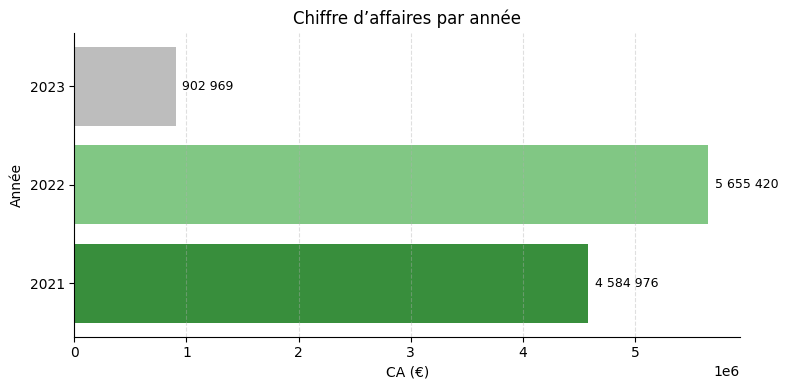

In [25]:
################################
#                              #
# RÉPARTITION DE СА PAR ANNÉES #
#                              #
################################

# Définir les couleurs : vert et gris
couleurs = ['#388E3C', '#81C784', '#BDBDBD']

# Trier les années par ordre croissant
ca_par_annee = ca_par_annee.sort_index()

# Créer une figure et des axes
fig, ax = plt.subplots(figsize=(8, 4))                                          # Définir la taille du graphique

# Créer un graphique à barres horizontales
barres = ax.barh(
    ca_par_annee.index.astype(str),                                             # Convertir les années en texte (labels de l'axe Y)
    ca_par_annee.values,                                                        # Valeurs de CA
    color=couleurs[:len(ca_par_annee)]                                          # Appliquer les couleurs dans l’ordre
)

# Ajouter les étiquettes sur chaque barre
for barre in barres:
    largeur = barre.get_width()                                                 # Obtenir la valeur de CA
    ax.text(
        largeur + max(ca_par_annee.values)*0.01,                                # Position X (légèrement à droite)
        barre.get_y() + barre.get_height() / 2,                                 # Centrer verticalement
        f'{int(largeur):,}'.replace(',', ' '),                                  # Ajouter des espaces pour les milliers
        va='center',                                                            # Aligner verticalement
        fontsize=9                                                              # Définir la taille du texte
    )

# Ajouter un titre clair
ax.set_title('Chiffre d’affaires par année', fontsize=12)                       # Définir la taille du texte

# Ajouter un label clair à l’axe horizontal
ax.set_xlabel('CA (€)', fontsize=10)                                            # Définir la taille du texte

# Ajouter un label clair à l’axe vertical
ax.set_ylabel('Année', fontsize=10)                                             # Définir la taille du texte

# Supprimer les bordures du haut et de droite pour un rendu plus propre
ax.spines['top'].set_visible(False)                                             # Supprimer le cadre supérieur du graphique
ax.spines['right'].set_visible(False)                                           # Supprimer le cadre droit du graphique

# Ajouter une légère grille pour faciliter la lecture
ax.xaxis.grid(True,                                                             # Définir l'indicateur pour afficher la grille
              linestyle='--',                                                   # Définir le style de ligne
              alpha=0.4)                                                        # Déterminer l'épaisseur de la ligne

# Appliquer une mise en page propre
plt.tight_layout()

# Afficher le graphique
plt.show()


**🔹 Dynamique de croissance en 2022**

Le chiffre d’affaires a fortement progressé en 2022 par rapport à 2021 (+23 %), ce qui peut témoigner de l’efficacité de la stratégie commerciale, des campagnes marketing ou de l’élargissement de la clientèle.

**🔹 Forte baisse en 2023**

Une chute brutale du chiffre d’affaires est constatée en 2023 (moins de 1 M€), ce qui nécessite une analyse urgente des causes : baisse d’activité des clients, problèmes d’assortiment, effet de saisonnalité, limitations de données ou période incomplète.

**🔹 Recommandation**

Il est nécessaire de réaliser une analyse détaillée par mois de l’année 2023 et par catégorie de clients/produits, afin d’identifier rapidement les causes de la baisse et d’y remédier.

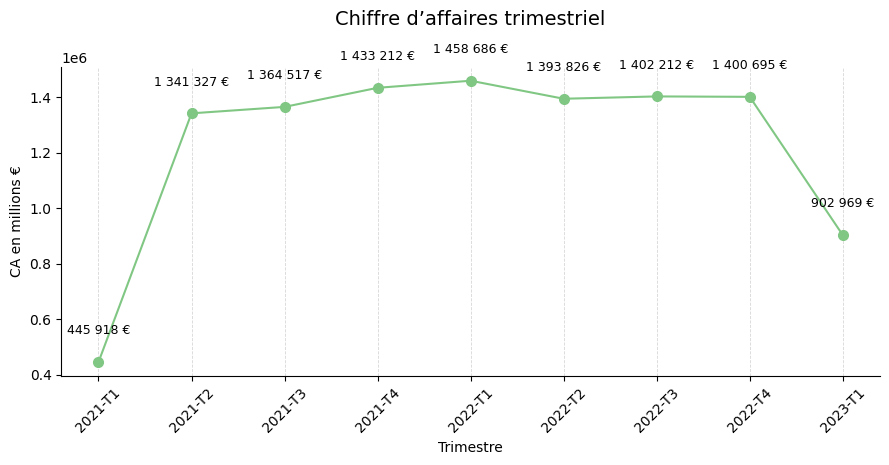

In [26]:
####################################
#                                  #
# RÉPARTITION DE СА PAR TRIMESTRES #
#                                  #
####################################

# Regrouper par années et trimestres + calcule la somme du СА (colonne "price")
ca_par_trimestre = df_merge.groupby(['année', 'trimestre'])['price'].sum()

# Créer une valeur au format année-trimestre sous la forme 2021-T1
ca_par_trimestre.index = [f"{a}-T{t}" for a, t in ca_par_trimestre.index]       # reformater l’index (année, trimestre) en une chaîne comme "2021-T1" pour lisibilité sur l’axe X

# Trier les données par ordre chronologique avant d’afficher le graphique
ca_par_trimestre = ca_par_trimestre.sort_index()

# Définir une couleur verte personnalisée pour la courbe
line_color = '#81C784'

# Créer une figure et une zone de dessin de taille 9 x 5 pouces
fig, ax = plt.subplots(figsize=(9, 5))

# Tracer la courbe avec des points visibles
ax.plot(
    ca_par_trimestre.index,                                                     # Axe X : les trimestres sous forme "AAAA-Tn"
    ca_par_trimestre.values,                                                    # Axe Y : les montants du chiffre d’affaires
    marker='o',                                                                 # On affiche un rond sur chaque point de la courbe
    markersize=7,                                                               # Taille des cercles
    linestyle='-',                                                              # Trait continu entre les points
    color=line_color                                                            # Couleur verte définie plus haut
)

# Ajouter les étiquettes de valeur au-dessus de chaque point
for i, value in enumerate(ca_par_trimestre.values):
    ax.text(
        i, value + 100000,                                                      # Position Y : un peu au-dessus du point pour ne pas le chevaucher
        f"{int(value):,} €".replace(",", " "),                                  # Format du texte : ajout du symbole €, avec espace pour les milliers
        ha='center', fontsize=9
    )

# Ajouter un titre avec une marge (pad) importante
ax.set_title("Chiffre d’affaires trimestriel", fontsize=14, pad=30)             # Titre du graphique avec une marge verticale supplémentaire pour aérer

# Ajouter les étiquettes des axes
ax.set_xlabel("Trimestre")                                                      # Légendes pour l'axe X
ax.set_ylabel("CA en millions €")                                               # Légendes pour l'axe Y

# Faire pivoter les étiquettes de l'axe X pour une meilleure lisibilité
plt.xticks(rotation=45)                                                         # Incliner les étiquettes sur l’axe X à 45° pour éviter les chevauchements

# Ajouter une grille discrète pour le fond
plt.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)                    # Une grille légère sur l’axe X pour faciliter la lecture des points

# Supprimer les bordures supérieure et droite du graphique
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)                                           # Nettoyage visuel du graphique pour un look plus moderne

# Ajuster la mise en page pour éviter tout chevauchement
plt.tight_layout(rect=[0, 0, 1, 0.95])                                          # Laisser un peu de marge en haut pour ne pas coller au bord du graphique

# Afficher le graphique
plt.show()

**Insights :**

**Croissance régulière en 2021 :** Après un faible démarrage en T1 2021 (482 440 €), le chiffre d’affaires a progressé de manière continue pour atteindre 1,54 M€ au T4 2021.

**Palier en 2022 :** Toute l’année 2022 se caractérise par un niveau élevé et stable de CA — autour de 1,5–1,57 M€ par trimestre. Cela traduit une phase de maturité et de saturation : la croissance ralentit, mais le volume de ventes reste solide.

**Forte baisse en T1 2023 :** Le CA est tombé à 974 220 €, soit près de –36 % par rapport au trimestre précédent. Cela peut être dû à une période d’observation incomplète (par ex. seulement janvier–février), ce qui doit être vérifié.

**Recommandations :**

* Maintenir le niveau de 2022 : reproduire les leviers qui ont permis la stabilité (campagnes, pics d’activité) et les intégrer dans une logique cyclique.
* Analyser la baisse en T1 2023 : vérifier si le trimestre est complet ; si oui, identifier rapidement les causes du recul (saisonnalité, offre, marketing).
* Explorer les moteurs de croissance 2021-T2 à 2021-T4 : comprendre ce qui a fonctionné (produit, canal, audience) afin de les répliquer ou de les amplifier.

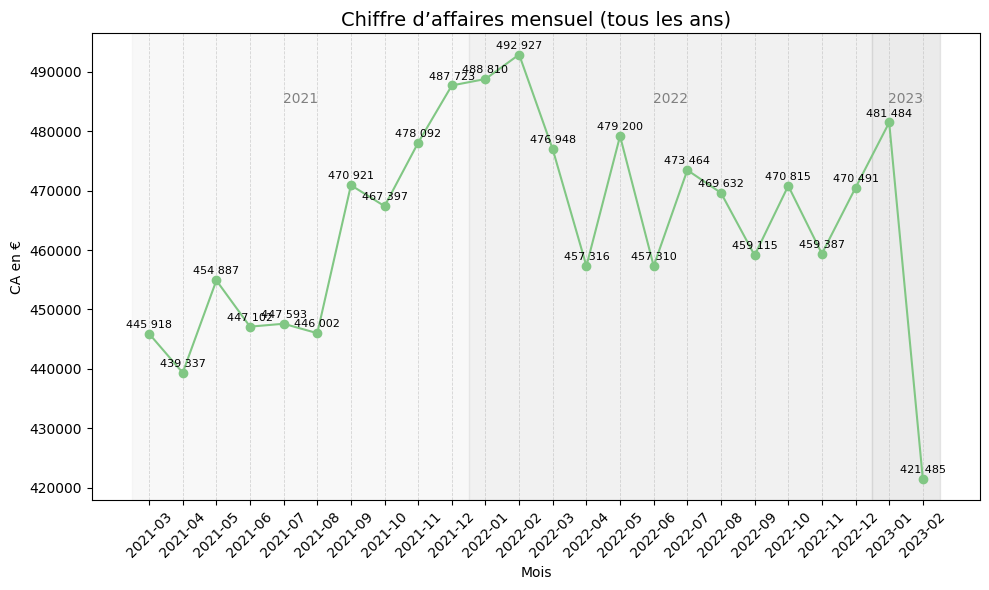

In [27]:
##############################
#                            #
# RÉPARTITION DE СА PAR MOIS #
#                            #
##############################

# Grouper CA par année et par année et mois + calculer la somme des ventes (CA)
ca_par_mois = df_merge.groupby(['année', 'mois'])['price'].sum()

# Formater les valeurs d'index année-mois comme 2021-03
ca_par_mois.index = [f"{a}-{str(m).zfill(2)}" for a, m in ca_par_mois.index]    # en chaîne de caractères de type "AAAA-MM" pour l’affichage sur le graphique

# Trier les données dans l’ordre chronologique (sinon, l’axe X serait désordonné)
ca_par_mois = ca_par_mois.sort_index()

# Create mois_labels from the index of ca_par_mois
mois_labels = ca_par_mois.index.tolist()                                        # la liste des mois formatés pour l’utiliser comme étiquettes de l’axe X

# Définir une couleur verte personnalisée pour la courbe
line_color = '#81C784'

# Créer un graphique linéaire
fig, ax = plt.subplots(figsize=(10, 6))                                         # une figure et un axe de taille 10 x 6 pouces

ax.plot(
    ca_par_mois.index,                                                          # Axe X : liste des mois formatés
    ca_par_mois.values,                                                         # Axe Y : les valeurs de chiffre d’affaires
    marker='o',                                                                 # On marque chaque point avec un cercle
    markersize=6,                                                               # Taille des cercles
    linestyle='-',                                                              # Ligne continue entre les points
    color=line_color                                                            # Couleur définie précédemment
)

# Remplir les zones correspondant à chaque année
positions = list(range(len(mois_labels)))                                       # une liste de positions (0, 1, 2, …) correspondant à chaque mois pour pouvoir ajouter les zones colorées par année

# Déterminer les bornes de chaque année
bornes = {}
for i, label in enumerate(mois_labels):
    année = label.split('-')[0]                                                 # Extraire l’année depuis le label du type "2021-03"
    if année not in bornes:
        bornes[année] = [i, i]                                                  # Si l’année n’est pas encore enregistrée, on initialise les bornes
    else:
        bornes[année][1] = i                                                    # Sinon, on met à jour la borne de fin pour cette année

# Définir une liste de couleurs grisées pour chaque année
couleurs_gris = ['#E0E0E0', '#BDBDBD', '#9E9E9E']                               # clair, moyen, foncé - 3 nuances de gris pour distinguer les années avec des bandes colorées

# Ajouter les bandes verticales pour chaque année avec différentes couleurs
for i, (année, (start, end)) in enumerate(bornes.items()):
    ax.axvspan(start - 0.5, end + 0.5, color=couleurs_gris[i % len(couleurs_gris)], alpha=0.2) # Pour chaque année, on ajoute une bande verticale grisée qui couvre les mois de cette année.

    ax.text((start + end) / 2,
            ax.get_ylim()[1] * 0.98,
            année,
            ha='center',                                                        # Afficher l’année au centre de chaque zone colorée
            va='top',
            fontsize=10,
            color='gray')

# Ajouter des valeurs au-dessus des points sur le graphique
for i, value in enumerate(ca_par_mois.values):
    plt.text(ca_par_mois.index[i],                                              # Position X : le mois correspondant
             value + 1000,                                                      # Position Y : un peu au-dessus de la valeur
             f"{int(value):,}".replace(",", " "),                               # Formatage avec des espaces pour les milliers
             ha='center',
             fontsize=8)

# Configurer d'affichage des éléments
plt.title("Chiffre d’affaires mensuel (tous les ans)", fontsize=14)             # Titre du graphique

# Étiquetter des axes X et Y
plt.xlabel("Mois")
plt.ylabel("CA en €")
plt.xticks(rotation=45)                                                         # Rotation de 45° pour faciliter la lecture des mois
plt.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)                    # Ajouter une grille discrète sur l’axe X pour améliorer la lisibilité
plt.tight_layout()                                                              # Ajustement automatique pour éviter les chevauchements de texte
plt.show()                                                                      # Affichage final du graphique

**🔹 CA mensuel stable**

Malgré une croissance annuelle en 2022, les valeurs mensuelles de CA restent dans une fourchette étroite (≈480K–535K €), ce qui témoigne d’une stabilité et d’une maturité du modèle économique.

**🔹 Pics en décembre**

Chaque année, on observe un pic en décembre (ex. 535 571 € en 2021, 510 219 € en 2022, 517 540 € en 2023), révélant une forte saisonnalité liée à la demande festive. Ce levier peut être exploité pour des campagnes ciblées et une gestion stratégique des stocks.

**🔹 Baisse en février 2023**

Février 2023 marque une chute brutale (456 679 €) — le plus bas niveau du graphique. Cela pourrait être lié à une baisse de l’activité, à des retards logistiques ou à l’émergence de problèmes structurels.

**🔹 Potentiel de croissance sur les « mois faibles »**

Certains mois affichent un plateau ou même un recul par rapport aux périodes équivalentes des autres années (ex. juin–juillet). Cela offre une opportunité d’interventions marketing ciblées.

**Recommandations :**

* Accentuer les efforts sur la campagne de décembre : c’est un moment stratégique.
* Développer des actions promotionnelles au printemps et en été, où la demande est stable mais en deçà du maximum.
* Examiner en détail les causes de la baisse début 2023 et ajuster la stratégie en conséquence.

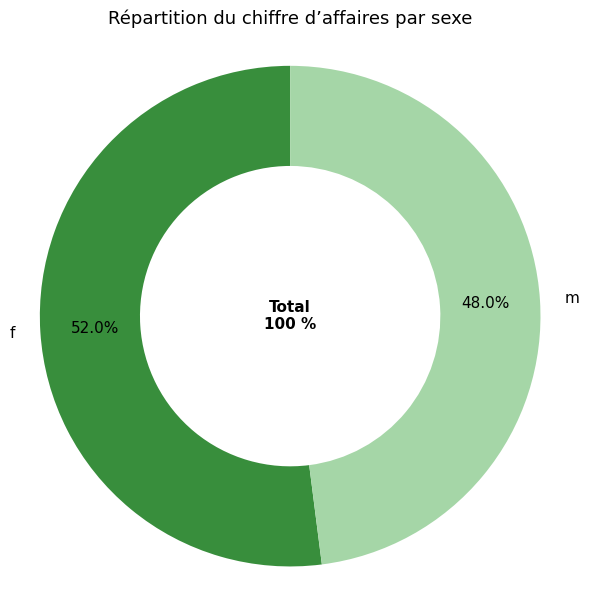

In [28]:
#########################################
#                                       #
# RÉPARTITION CA PAR SEXE DE L'ACHETEUR #
#                                       #
#########################################

# Calcul du chiffre d'affaires par sexe
ca_par_sexe = df_merge.groupby('sex')['price'].sum().sort_values(ascending=False)

# Définir les labels et les tailles (valeurs)
labels = ca_par_sexe.index.tolist()
sizes = ca_par_sexe.values

# Couleurs pour f et m (vert foncé / vert clair)
colors = ['#388E3C', '#A5D6A7']

# Créer la figure
fig, ax = plt.subplots(figsize=(6, 6))

# Diagramme en anneau
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4)
)

# Styliser les textes extérieurs
for text in texts:
    text.set_fontsize(11)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color('black')
    x, y = autotext.get_position()
    autotext.set_position((x * 1.3, y * 1.3))

# Ajouter le total au centre
ax.text(0, 0, 'Total\n100 %', ha='center', va='center', fontsize=11, fontweight='bold')

# Titre
ax.set_title("Répartition du chiffre d’affaires par sexe", fontsize=13, pad=20)

# Cercle parfait
ax.axis('equal')

# Affichage
plt.tight_layout()
plt.show()


**🔹 CA hommes vs femmes — quasi-égalité**

La part des hommes représente 50,2 % du chiffre d’affaires total, contre 49,8 % pour les femmes, ce qui indique un équilibre presque parfait de l’activité d’achat entre les deux groupes.

**Recommandations :**

* Maintenir des campagnes marketing neutres par rapport au genre, puisque les deux audiences sont également actives.
* Le cas échéant, renforcer le ciblage en fonction des catégories de produits plutôt que du sexe — les comportements étant presque identiques.

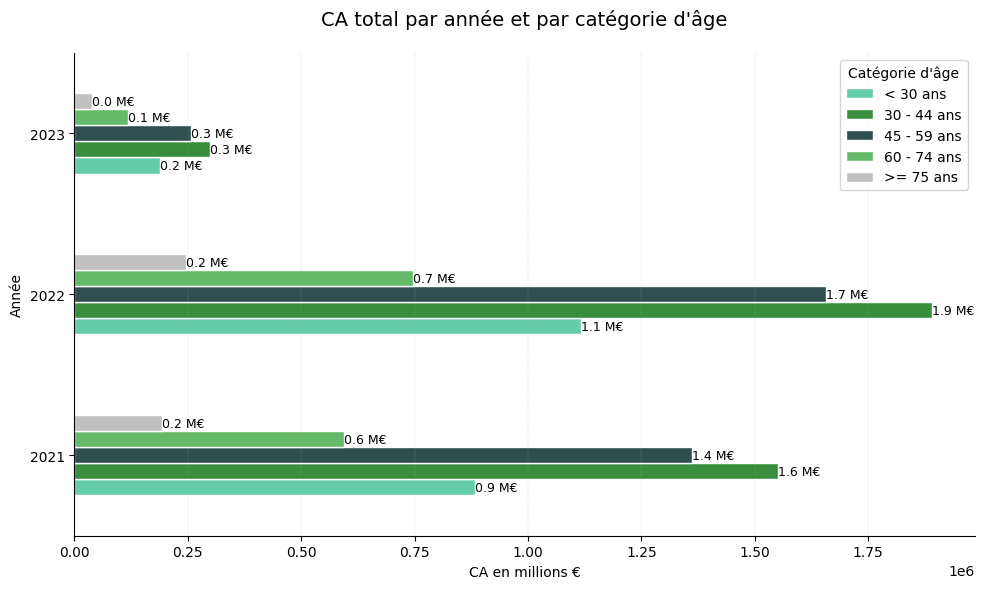

In [29]:
#####################################################
#                                                   #
# RÉPARTITION CA PAR ANNÉE AVEC RÉPARTITION PAR ÂGE #
#                                                   #
#####################################################

import matplotlib.pyplot as plt
# Regrouper les données : ligne = année, colonnes = catégories d'âge, valeurs = somme du CA
ca_par_annee_age = df_merge.groupby(['année', 'cat_age'])['price'].sum().unstack()

# Définir une palette personnalisée : tons verts et gris
colors = ['#66CDAA', '#388E3C', '#2F4F4F', '#66BB6A', '#C0C0C0']                # Couleurs pour chaque tranche d'âge

# Trier manuellement les catégories d'âge dans un ordre logique
ordre_categories = ['< 30 ans', '30 - 44 ans', '45 - 59 ans', '60 - 74 ans', '>= 75 ans']
ca_par_annee_age = ca_par_annee_age[ordre_categories]                           # Réorganiser les colonnes selon cet ordre

# Créer un graphique à barres horizontales
ax = ca_par_annee_age.plot(
    kind='barh',                                                                # Type : barres horizontales
    figsize=(10, 6),                                                            # Taille du graphique
    color=colors,                                                               # Appliquer les couleurs définies
    edgecolor='white'                                                           # Couleur des bordures entre les barres
)

# Ajouter un titre et des étiquettes d’axes
plt.title("CA total par année et par catégorie d'âge",
          fontsize=14,                                                          # Taille de la police
          pad=20)                                                               # Espacement avec le graphique
plt.xlabel("CA en millions €")                                                  # Nom de l’axe X
plt.ylabel("Année")                                                             # Nom de l’axe Y

# Ajouter les valeurs numériques sur chaque barre
for bars in ax.containers:
    ax.bar_label(
        bars,
        fmt=lambda x: f"{x/1_000_000:.1f} M€",                                  # Formater en millions avec suffixe "M€"
        label_type='edge',                                                      # Placer les étiquettes au bord de chaque barre
        fontsize=9                                                              # Taille de police des étiquettes
    )

# Ajouter la légende à l’intérieur du graphique
ax.legend(
    title="Catégorie d'âge",                                                    # Titre de la légende
    loc='upper right',                                                          # Emplacement : coin supérieur droit
    frameon=True                                                                # Afficher un cadre autour de la légende
)

# Ajouter une grille verticale discrète pour faciliter la lecture
ax.grid(
    axis='x',                                                                   # Appliquer la grille seulement à l’axe X
    linestyle='--',                                                             # Ligne en pointillés
    linewidth=0.3,                                                              # Épaisseur fine
    alpha=0.5                                                                   # Transparence
)

# Supprimer les bordures supérieures et droites du cadre
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajuster automatiquement les marges pour éviter les chevauchements
plt.tight_layout()

# Afficher le graphique final
plt.show()

**🔹 1. Leaders en chiffre d’affaires — clients de 45–59 ans et 60–74 ans**

Ces deux catégories d’âge génèrent la majeure partie des ventes chaque année. En 2022, leur contribution est presque équivalente (environ 2 M€ chacune), ce qui en fait des segments stratégiquement clés.

**🔹 2. La catégorie 30–44 ans en retrait**

Bien que cette tranche d’âge soit active dans d’autres secteurs, sa contribution au CA reste plus faible, notamment en comparaison avec les groupes voisins.

**🔹 3. Clients de moins de 30 ans et de 75 ans et plus quasi inexistants**

Les catégories <30 ans et ≥75 ans affichent de manière constante un CA faible. Cela peut refléter un manque d’attractivité de l’offre ou une stratégie marketing peu adaptée à ces segments.

**Recommandations :**

* Consolider et fidéliser les clients de 45–74 ans via des programmes de loyauté et des offres personnalisées.
* Repenser la stratégie pour les 30–44 ans — ajustement des canaux ou de l’assortiment.
* Ne pas investir massivement dans les segments <30 et ≥75 sans une analyse approfondie de leur potentiel.

In [30]:
################
#              #
# CA PAR CLENT #
#              #
################

# Calcul du chiffre d'affaires par client
ca_par_client = df_merge.groupby('client_id')['price'].sum().sort_values(ascending=False)

# Afficher les 20 meilleurs clients
print(ca_par_client.head(20))


client_id
c_1570    5285.82
c_3263    5276.87
c_2140    5260.18
c_2899    5214.05
c_7319    5155.77
c_7959    5135.75
c_1422    5131.36
c_7421    5097.18
c_8026    5082.58
c_2505    5059.35
c_1876    5026.60
c_4491    5025.05
c_5263    5006.85
c_2595    4959.66
c_8392    4934.01
c_880     4897.19
c_8510    4888.16
c_1636    4883.56
c_2077    4848.06
c_4840    4826.51
Name: price, dtype: float64


**🔹 Absence de forte concentration sur quelques clients**

Pour chacun du top 20, le chiffre d’affaires se situe autour de ~4 800–5 300 €.
L’écart entre le premier (c_1570) et le vingtième (c_4840) est minime (<10 %).
Cela traduit une structure de revenus équilibrée, sans dépendance à des « super-clients ».

**🔹 Réduction du risque de churn**

Contrairement au segment B2B (où un seul client peut générer des centaines de milliers d’euros), le B2C est plus résilient : la perte d’un client ≈ <0,05 % du CA total.

**🔹 Potentiel de segmentation et de fidélisation**

Ces clients représentent le noyau de la base retail.
Il serait pertinent d’analyser plus finement leur comportement : fréquence d’achat, catégories de produits, saisonnalité. Cela ouvre la voie à des programmes de fidélité pour stimuler les achats répétés.

**🔹 Focus stratégique**

Au lieu de dépendre de quelques « géants » (comme en B2B), l’entreprise doit miser sur la masse de clients retail.
Avec une gestion adaptée, ce modèle est scalable sans risque de dépendance excessive.

**Conclusion :** l’entreprise dispose d’un portefeuille de clients retail bien équilibré. Cela réduit les risques et crée des opportunités de croissance via le marketing et la fidélisation.



---


---


**Comment choisir la fenêtre pour un calcul correct de moyenne mobile?**

* **Pour l'analyse par année :** 2 ans (réaction rapide et adapté aux présentations avec un historique court) ou 3 ans (tendance plus régulière, adapté aux conclusions stratégiques). **Règle :** si la série est ≤ 4 ans, il vaut mieux prendre 2 ; si elle est ≥ 5 ans, il vaut mieux prendre 3.

* **Pour l'analyse trimestrielle :** 4 trimestres  (lisse la saisonnalité, mais conserve la dynamique) ou 6 à 8 trimestres (pour une tendance plus stable). **Règle :** en cas de forte saisonnalité, il vaut mieux commencer par 4, pour une vision « à long terme », il vaut mieux prendre une fenêtre de 6/8.

* **Pour l'analyse mensuelle :** 3 mois (lissage doux, vue trimestrielle), 6 mois (tendance semestrielle, équilibre entre fluidité et réactivité), 12 mois (supprime complètement la saisonnalité annuelle). **Règle :** pour présenter les données sous leur forme brute, il convient de prendre 3/6,  pour une tendance brute sans saisonnalité, il convient de prendre 12.

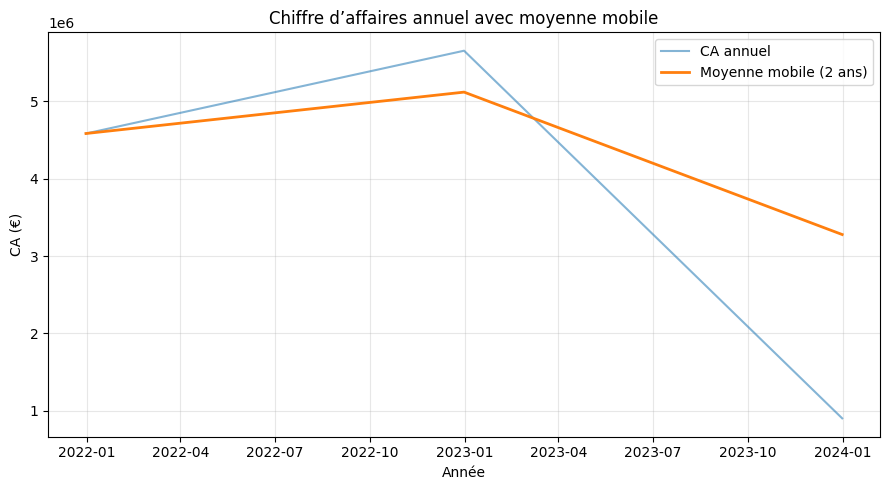

In [68]:
##############################################
#                                            #
# Chiffre d’affaires annuel + moyenne mobile #
#                                            #
##############################################

W_YEARS = 2  # fenêtre de moyenne mobile (2 ans)

# Agrégation annuelle
df_y = (df_merge.assign(date=pd.to_datetime(df_merge['date']))
                 .set_index('date')
                 .resample('YE')['price'].sum()
                 .rename('CA'))

# Moyenne mobile
df_y_ma = df_y.rolling(window=W_YEARS, min_periods=1).mean().rename(f'MA_{W_YEARS}a')

# Tracé
plt.figure(figsize=(9,5))
plt.plot(df_y.index, df_y, label='CA annuel', alpha=0.55)
plt.plot(df_y_ma.index, df_y_ma, label=f'Moyenne mobile ({W_YEARS} ans)', linewidth=2)
plt.title("Chiffre d’affaires annuel avec moyenne mobile")
plt.xlabel("Année")
plt.ylabel("CA (€)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Observations :** en 2022, le chiffre d'affaires a augmenté par rapport à 2021, ce qui reflète une période fructueuse pour l'entreprise. En 2023, une forte baisse a été enregistrée, et la moyenne mobile aide à lisser ce déclin, montrant une tendance à plus long terme.

**La tendance générale** de la ligne moyenne indique que la croissance a été instable et qu'en 2023-2024, l'entreprise est entrée dans une phase de déclin, ce qui nécessite une analyse des causes (saisonnalité, demande, gamme de produits, marketing).

**Recommandations :**

* Analyser l'échec de 2023 par mois/catégorie/campagne : trouver les sources de la baisse (assortiment, prix, logistique, trafic, conversion) et définir des mesures de redressement.

* Concentrer le marketing sur les moteurs de chiffre d'affaires « rapides » (catégories phares, best-sellers, canaux à forte conversion) et lancer des séries promotionnelles pendant les périodes de pointe.

* Renforcer la fidélisation : offres personnalisées pour les segments actifs de 2022, réactivation des clients « dormants », ventes croisées et offres groupées pour augmenter le panier moyen.

**Prévisions + scénarios :** utiliser une moyenne mobile sur 2 à 3 ans pour le plan-fait, fixer des objectifs trimestriels et surveiller les écarts chaque mois.

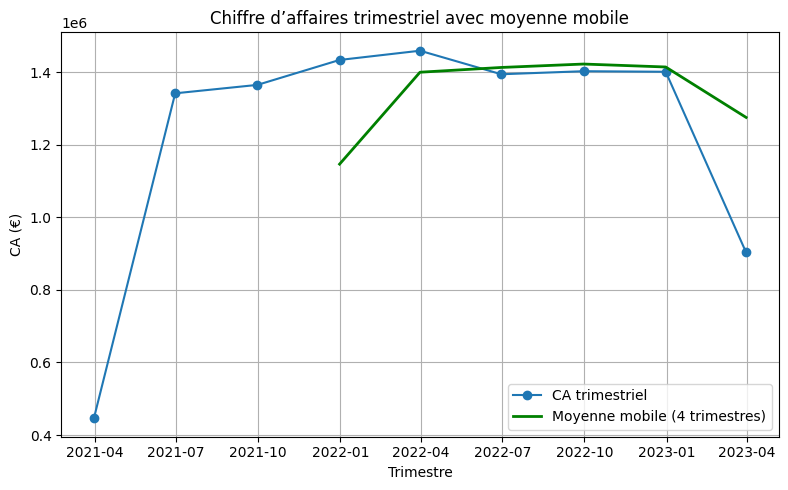

In [69]:
###################################################
#                                                 #
# Chiffre d’affaires trimestriel + moyenne mobile #
#                                                 #
###################################################

# Agrégation trimestrielle (fin de trimestre)
df_q = (df_merge.assign(date=pd.to_datetime(df_merge['date']))
                .set_index('date')
                .resample('QE')['price'].sum()   # 'QE' = Quarter End
                .rename('CA'))

# Moyenne mobile sur 4 trimestres
df_q_mm = df_q.rolling(window=4).mean()

# Visualisation
plt.figure(figsize=(8,5))
plt.plot(df_q.index, df_q, marker='o', label="CA trimestriel")
plt.plot(df_q_mm.index, df_q_mm, color='green', linewidth=2, label="Moyenne mobile (4 trimestres)")
plt.title("Chiffre d’affaires trimestriel avec moyenne mobile")
plt.xlabel("Trimestre")
plt.ylabel("CA (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations :** après un premier trimestre 2021 plus faible, le chiffre d’affaires trimestriel connaît une croissance rapide et atteint un maximum début 2022. Ensuite, une stabilisation relative s’installe, avec des valeurs autour de 1,4 million d’euros par trimestre. En 2023, une baisse est observée, confirmée par la tendance de la moyenne mobile.

**La tendance générale :** la courbe montre que la croissance forte de 2021-2022 a été suivie d’une phase de maturité en 2022 (stabilité autour d’un plateau élevé), avant un retournement début 2023. La moyenne mobile illustre que la tendance générale est passée d’une croissance soutenue à une stagnation, puis à un début de déclin.

**Recommandations :**

* Étudier les baisses au niveau trimestriel en 2023 (catégories, clients, saisonnalité) pour identifier les segments responsables.

* Lancer des campagnes marketing ciblées avant et pendant les trimestres clés (T2 et T4) pour profiter de la demande saisonnière.

* Ajuster les stocks et l’assortiment en fonction des pics récurrents observés en fin d’année.

**Prévisions + scénarios :** utiliser une moyenne mobile sur 4 trimestres pour prévoir les tendances et fixer des objectifs de croissance trimestriels réalistes, tout en surveillant les écarts avec les résultats réels pour agir rapidement.

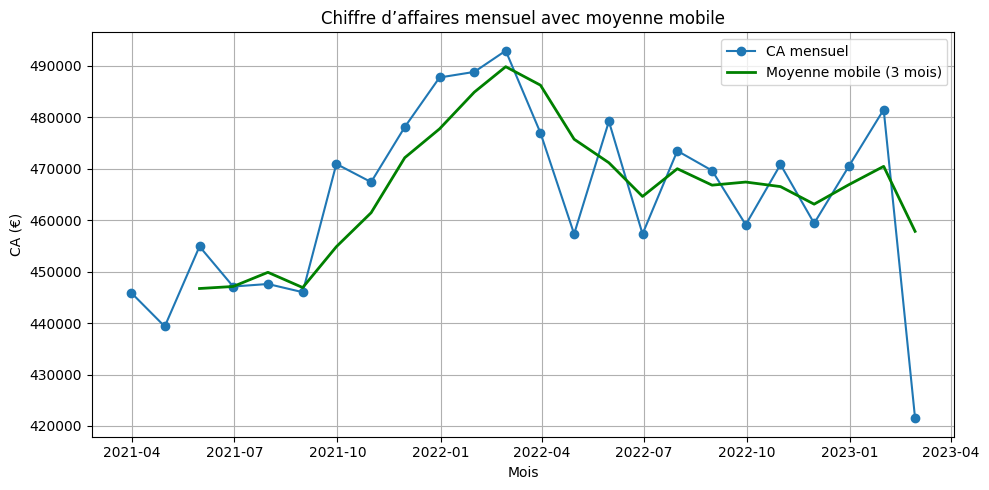

In [67]:
################################################
# Chiffre d’affaires mensuel + moyenne mobile  #
################################################

# Agrégation mensuelle (fin de mois)
df_m = (df_merge.assign(date=pd.to_datetime(df_merge['date']))
                .set_index('date')
                .resample('ME')['price'].sum()   # 'ME' = Month End
                .rename('CA'))

# Moyenne mobile sur 3 mois
df_m_mm = df_m.rolling(window=3).mean()

# Visualisation
plt.figure(figsize=(10,5))
plt.plot(df_m.index, df_m, marker='o', label="CA mensuel")
plt.plot(df_m_mm.index, df_m_mm, color='green', linewidth=2, label="Moyenne mobile (3 mois)")
plt.title("Chiffre d’affaires mensuel avec moyenne mobile")
plt.xlabel("Mois")
plt.ylabel("CA (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations :** le chiffre d’affaires mensuel présente une variabilité importante, avec des hausses marquées en fin 2021 et début 2022 (jusqu’à près de 490 000 €), suivies d’une tendance à la baisse au cours de 2023. La moyenne mobile sur 3 mois adoucit ces variations et confirme une dynamique de stabilisation autour de 470 000 € avant le déclin.

**La tendance générale :** on observe une saisonnalité claire : les pics récurrents en fin d’année (décembre) traduisent un effet des fêtes, alors que certains creux apparaissent en début d’année. En 2023, la baisse se renforce, ce qui traduit une rupture par rapport au cycle saisonnier habituel.

**Recommandations :**

* Exploiter les pics de fin d’année avec des campagnes marketing ciblées et des promotions.

* Étudier les creux récurrents (janvier-février) pour renforcer les ventes par des offres spéciales hors saison.

* Surveiller mensuellement les décalages par rapport à la moyenne mobile pour détecter rapidement des anomalies (chute de demande, problème logistique, etc.).

**Prévisions + scénarios :** utiliser la moyenne mobile sur 3 mois comme outil de suivi opérationnel, définir des seuils d’alerte et ajuster les prévisions en fonction de la saisonnalité et des tendances observées.

## 2. Clients

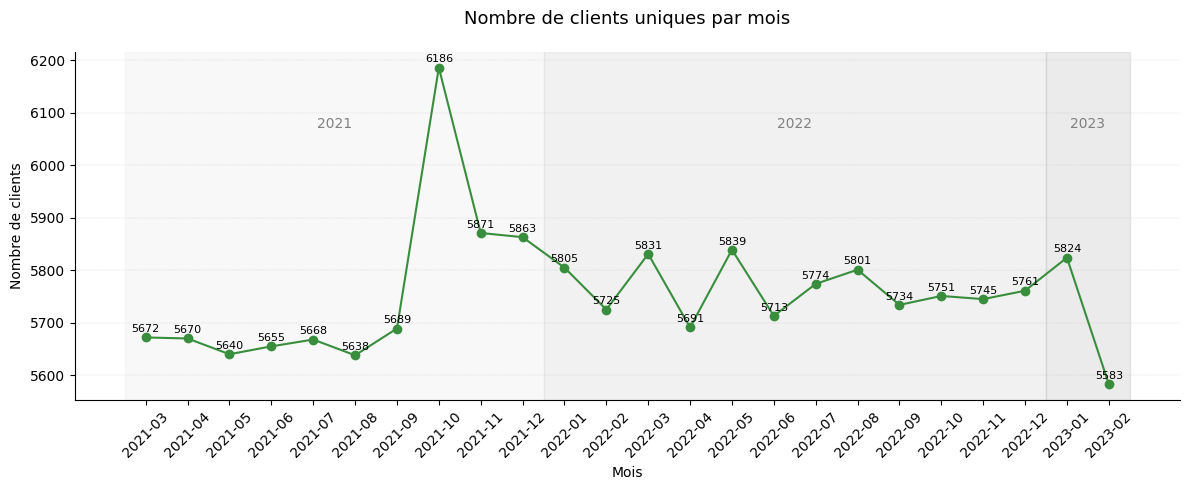

In [32]:
##############################
#                            #
# NOMBRE DE CLIENTS PAR MOIS #
#                            #
##############################

# Grouper par année et mois et compter les clients uniques
clients_par_mois = df_merge.groupby(['année', 'mois'])['client_id'].nunique()

# Recréer un index sous forme année-mois (ex. 2021-03)
clients_par_mois.index = [f"{a}-{str(m).zfill(2)}" for a, m in clients_par_mois.index]

# Trier l’index pour un affichage chronologique
clients_par_mois = clients_par_mois.sort_index()

# Créer le graphique
fig, ax = plt.subplots(figsize=(12, 5))                                         # Créer une figure et un axe avec une taille de 12x5 pouces

# Tracer la courbe des clients par mois
ax.plot(
    clients_par_mois.index,                                                     # Axe X : étiquettes mois
    clients_par_mois.values,                                                    # Axe Y : nombre de clients uniques
    marker='o',                                                                 # Marqueur circulaire sur chaque point
    linestyle='-',                                                              # Ligne continue
    color='#388E3C',                                                            # Couleur verte foncée
    markersize=6                                                                # Taille des marqueurs
)

# Ajouter les valeurs numériques au-dessus de chaque point
for i, value in enumerate(clients_par_mois.values):                             # Parcourir chaque valeur de clients mensuels avec son index
    ax.text(i,                                                                  # Position horizontale du texte (index du point sur l’axe X)
            value + 10,                                                         # Position verticale du texte (juste au-dessus du point)
            str(value),                                                         # Contenu du texte : convertir la valeur numérique en chaîne
            ha='center',                                                        # Centrer horizontalement le texte par rapport au point
            fontsize=8)                                                         # Définir la taille de la police du texte


# Préparer les positions pour les bandes d’années
mois_labels = clients_par_mois.index.tolist()
positions = list(range(len(mois_labels)))

# Déterminer les bornes de chaque année (début et fin) pour mettre en évidence visuellement chaque zone annuelle (par remplissage ou étiquettes) sur un graphique tracé par mois
bornes = {}                                                                     # Créer un dictionnaire vide pour stocker les positions de début et de fin de chaque année
for i, label in enumerate(mois_labels):                                         # Parcourir chaque étiquette de mois avec son index (ex. '2021-03', '2021-04', etc.)
    année = label.split('-')[0]                                                 # Extraire l’année depuis l’étiquette (ex. '2021' à partir de '2021-03')
    if année not in bornes:                                                     # Si l’année n’a pas encore été ajoutée au dictionnaire
        bornes[année] = [i, i]                                                  # Initialiser ses bornes avec l’index actuel comme début et fin (temporairement identiques)
    else:
        bornes[année][1] = i                                                    # Mettre à jour la borne de fin avec l’index courant (le plus récent pour cette année)


# Couleurs pour les zones par année (nuances de gris)
couleurs_gris = ['#E0E0E0', '#BDBDBD', '#9E9E9E']

# Ajouter les bandes verticales pour chaque année avec une couleur différente
for i, (année, (start, end)) in enumerate(bornes.items()):                      # Parcourir chaque année avec ses bornes (début et fin sur l’axe X)
    ax.axvspan(start - 0.5,                                                     # Définir le début de la bande : légèrement avant le premier mois de l’année
               end + 0.5,                                                       # Définir la fin de la bande : légèrement après le dernier mois de l’année
               color=couleurs_gris[i % len(couleurs_gris)],                     # Appliquer une couleur grise différente pour chaque année (en boucle)
               alpha=0.2)                                                       # Définir la transparence de la bande (0 = invisible, 1 = opaque)

    ax.text((start + end) / 2,                                                  # Position horizontale du texte : au centre de la zone de l’année
            ax.get_ylim()[1] * 0.98,                                            # Position verticale du texte : tout en haut du graphique (98% de la hauteur max)
            année,                                                              # Texte affiché : l’année concernée (ex. "2021")
            ha='center',                                                        # Aligner horizontalement le texte au centre
            va='top',                                                           # Aligner verticalement le texte en haut
            fontsize=10,                                                        # Taille de la police
            color='gray')                                                       # Couleur grise du texte pour rester discret sur le fond coloré

# Ajouter un titre et les axes
ax.set_title("Nombre de clients uniques par mois", fontsize=13, pad=20)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de clients")

# Positionner les étiquettes de l’axe X
ax.set_xticks(range(len(clients_par_mois.index)))
ax.set_xticklabels(clients_par_mois.index, rotation=45)

# Ajouter une grille horizontale légère
ax.grid(axis='y', linestyle='--', linewidth=0.3, alpha=0.5)

# Supprimer les bordures hautes et droites
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajustement automatique de la mise en page
plt.tight_layout()

# Afficher le graphique
plt.show()


**Observation principale :**

Le nombre de clients uniques par mois reste globalement stable, avec des variations limitées à ±200–300 clients. Un pic marqué apparaît en octobre 2021 — 6 190 clients, soit +10 % par rapport au niveau moyen. Après ce pic, la tendance retrouve sa stabilité, sans signe de croissance ou de déclin durable.

Le pic d’octobre 2021 peut être lié : à une campagne marketing, des soldes ou une promotion ; à un effet saisonnier (par ex. la rentrée ou la préparation de Noël). Le recul de janvier–février 2023 peut indiquer : un creux saisonnier ; une baisse d’activité ou d’efforts marketing ; une contraction de la base clients.

**Recommandations :**

* Analyser les actions d’octobre 2021 : quels canaux, offres ou produits ont généré ce pic ? → à reproduire.
* Maintenir une activité marketing régulière pour éviter les baisses brutales, surtout en début d’année.
* Lancer des campagnes de fidélisation ou d’email remarketing durant les mois faibles (ex. février 2023) pour lisser la saisonnalité.
* Surveiller les métriques de rétention : la stabilité sans croissance peut signaler une stratégie d’acquisition peu efficace.

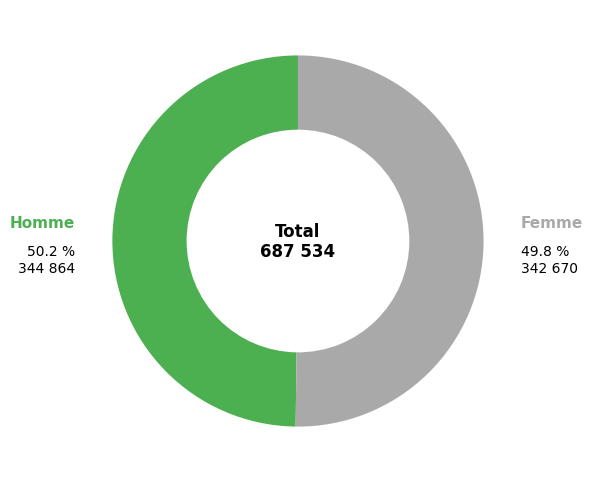

In [33]:
#####################################
#                                   #
# RÉPARTITION DES CLIENTS PAR SEXE  #
#                                   #
#####################################

# Définir les variables
labels = ['Femme', 'Homme']                                                     # Définir les étiquettes pour les deux catégories
sizes = [49.8, 50.2]                                                            # Définir les pourcentages correspondant à chaque catégorie
absolute = [342670, 344864]                                                     # Définir les valeurs absolues (nombre de clients) par catégorie
colors = ['#4CAF50', '#A9A9A9']                                                 # Définir les couleurs utilisées : vert pour femmes, gris pour hommes
total = sum(absolute)                                                           # Calculer le total des clients pour affichage au centre du graphique

# Créer le graphique en anneau
fig, ax = plt.subplots(figsize=(6, 6))                                          # Créer une figure et un axe de taille 6x6 pouces
wedges, texts = ax.pie(                                                         # Créer un graphique circulaire (pie chart)
    sizes,                                                                      # Définir les proportions de chaque segment
    labels=None,                                                                # Ne pas afficher de labels directement sur les segments
    colors=colors,                                                              # Appliquer les couleurs définies (vert et gris)
    startangle=90,                                                              # Faire commencer le premier segment à 90° (en haut)
    wedgeprops=dict(width=0.4),                                                 # Définir l’épaisseur de l’anneau (donut) à 40 % du rayon
)

# Ajouter le nombre total au centre du donut
ax.text(
    0,                                                                          # Définir la position horizontale du texte (centre = 0)
    0,                                                                          # Définir la position verticale du texte (centre = 0)
    f'Total\n{total:,}'.replace(',', ' '),                                      # Afficher le texte avec le total, formaté avec un retour à la ligne et des espaces pour les milliers
    ha='center',                                                                # Aligner horizontalement le texte au centre
    va='center',                                                                # Aligner verticalement le texte au centre
    fontsize=12,                                                                # Définir la taille du texte
    fontweight='bold'                                                           # Afficher le texte en gras
)

# Ajouter les étiquettes sur les côtés

# À droite : Femme
ax.text(
    1.2,                                                                        # Définir la position horizontale du mot "Femme" (à droite du donut)
    0.1,                                                                        # Définir la position verticale légèrement au-dessus du centre
    'Femme',                                                                    # Afficher le mot "Femme"
    ha='left',                                                                  # Aligner le texte à gauche de la position x
    va='center',                                                                # Aligner le texte verticalement au centre
    fontsize=11,                                                                # Définir la taille du texte
    fontweight='bold',                                                          # Afficher le texte en gras
    color=colors[1])                                                            # Appliquer la couleur correspondante (gris)

ax.text(
    1.2,                                                                        # Définir la position horizontale du pourcentage et de la valeur (même x que ci-dessus)
    -0.1,                                                                       # Positionner légèrement en dessous du centre
    f"{sizes[0]:.1f} %\n{absolute[0]:,}".replace(',', ' '),                     # Afficher le pourcentage et la valeur absolue formatée
    ha='left',                                                                  # Aligner le texte à gauche
    va='center',                                                                # Aligner verticalement au centre
    fontsize=10                                                                 # Définir la taille du texte
)

# À gauche : Homme
ax.text(
    -1.2,                                                                       # Définir la position horizontale du mot "Homme" (à gauche du donut)
    0.1,                                                                        # Définir la position verticale légèrement au-dessus du centre
    'Homme',                                                                    # Afficher le mot "Homme"
    ha='right',                                                                 # Aligner le texte à droite de la position x
    va='center',                                                                # Aligner le texte verticalement au centre
    fontsize=11,                                                                # Définir la taille du texte
    fontweight='bold',                                                          # Afficher le texte en gras
    color=colors[0])                                                            # Appliquer la couleur correspondante (vert)

ax.text(
    -1.2,                                                                       # Définir la position horizontale du pourcentage et de la valeur (même x que ci-dessus)
    -0.1,                                                                       # Positionner légèrement en dessous du centre
    f"{sizes[1]:.1f} %\n{absolute[1]:,}".replace(',', ' '),                     # Afficher le pourcentage et la valeur absolue formatée
    ha='right',                                                                 # Aligner le texte à droite
    va='center',                                                                # Aligner verticalement au centre
    fontsize=10                                                                 # Définir la taille du texte
)


# Ajuster l'aspect pour un cercle parfait
ax.set(aspect="equal")                                                          # Forcer l'axe à avoir une échelle égale pour assurer un cercle régulier
plt.tight_layout()                                                              # Optimiser l'espacement automatique des éléments de la figure
plt.show()

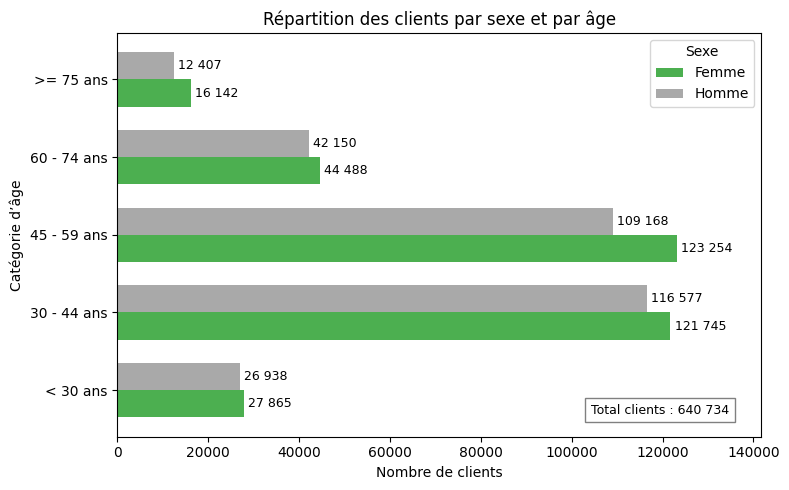

In [34]:
#######################################################
#                                                     #
# RÉPARTITION DES CLIENTS PAR SEXE ET CATÉGORIE D'ÂGE #
#                                                     #
#######################################################

# Calculer le nombre de clients par catégorie d'âge et par sexe
df_counts = df_merge.groupby(['cat_age', 'sex']).size().unstack(fill_value=0)

# Renommer les colonnes pour afficher 'Femme' et 'Homme' dans la légende
df_counts_named = df_counts.rename(columns={'f': 'Femme', 'm': 'Homme'})        # Renommer les abréviations pour les rendre lisibles

# Réorganiser les catégories d’âge dans le bon ordre
ordre_categories = ['< 30 ans', '30 - 44 ans', '45 - 59 ans', '60 - 74 ans', '>= 75 ans']   # Définir l'ordre logique des tranches d'âge
df_counts_named = df_counts_named.reindex(ordre_categories)                     # Réordonner les lignes selon cet ordre

# Définir les couleurs : vert pour femmes, gris pour hommes
colors = ['#4CAF50', '#A9A9A9']                                                 # Spécifier les couleurs des barres pour chaque sexe

# Créer un graphique à barres horizontales
ax = df_counts_named.plot(
    kind='barh',                                                                # Spécifier un graphique à barres horizontales
    figsize=(8, 5),                                                             # Définir la taille de la figure
    title='Répartition des clients par sexe et par âge',                        # Ajouter un titre
    color=colors,                                                               # Appliquer les couleurs définies
    width=0.7                                                                   # Ajuster la largeur des barres
)

# Ajuster les limites de l’axe X pour ne pas couper les étiquettes
max_value = df_counts_named.max().max()                                         # Identifier la valeur maximale parmi toutes les barres
plt.xlim(0, max_value * 1.15)                                                   # Étendre la limite droite de l'axe X de 15 %

# Afficher les valeurs exactes à côté de chaque barre
for container in ax.containers:                                                 # Parcourir chaque groupe de barres (homme, femme)
    ax.bar_label(
        container,                                                              # Cibler le groupe de barres
        label_type='edge',                                                      # Afficher la valeur au bord de la barre
        fontsize=9,                                                             # Définir la taille du texte
        fmt=lambda x: f'{int(x):,}'.replace(',', ' '),                          # Formater les nombres avec des espaces pour les milliers
        padding=3                                                               # Ajouter un petit espace entre la barre et l’étiquette
    )

# Afficher le total de clients en bas à droite
total_clients = df_counts_named.sum().sum()                                     # Calculer le nombre total de clients toutes catégories confondues
ax.text(
    0.95,                                                                       # Position horizontale dans le repère des axes (95 % à droite)
    0.05,                                                                       # Position verticale (5 % en bas)
    f'Total clients : {int(total_clients):,}'.replace(',', ' '),                # Formater le total avec des espaces
    transform=ax.transAxes,                                                     # Utiliser les coordonnées relatives à l'axe
    ha='right',                                                                 # Aligner le texte à droite
    va='bottom',                                                                # Aligner le texte en bas
    fontsize=9,                                                                 # Définir la taille de la police
    bbox=dict(facecolor='white', edgecolor='gray')                              # Ajouter une boîte blanche avec bordure grise autour du texte
)

# Nommer les axes
plt.xlabel("Nombre de clients")                                                 # Nommer l'axe horizontal
plt.ylabel("Catégorie d’âge")                                                   # Nommer l'axe vertical

# Afficher la légende avec titre
ax.legend(
    title='Sexe',                                                               # Ajouter un titre à la légende
    loc='upper right')                                                          # Positionner la légende en haut à droite

# Appliquer une mise en page propre
plt.tight_layout()                                                              # Ajuster automatiquement les marges pour éviter les chevauchements

# Afficher le graphique final
plt.show()

**Insights :**

* Deux groupes d’âge dominants : Les catégories 45–59 ans et 30–44 ans sont les plus importantes en nombre de clients. Ensemble, elles représentent plus de 70 % de la base totale.

* Équilibre hommes-femmes : Dans toutes les tranches d’âge, sauf ≥75 ans, la répartition hommes/femmes est presque égale. Chez les clients âgés (75+), on observe une forte prédominance masculine.

* Jeunes (<30 ans) : Ce segment est nettement plus restreint (4–5 fois moins nombreux que les groupes dominants). Cela peut traduire un potentiel inexploité ou un faible intérêt des jeunes pour l’offre actuelle.

**Recommandations :**

* Cibler la fidélisation et la monétisation des 30–59 ans : offres personnalisées, réductions, programmes de fidélité adaptés à leurs profils.
* Développer une stratégie pour les moins de 30 ans : analyser leurs besoins, envisager une gamme dédiée ou un marketing via réseaux sociaux et messageries.
* Analyser le segment 75+ : comprendre pourquoi les hommes y sont deux fois plus nombreux ; vérifier la qualité des données ou les canaux d’acquisition.
* Campagnes neutres en termes de genre : la répartition hommes/femmes étant équilibrée, la communication doit rester également pertinente pour les deux audiences.

## 3. Produits


[30208, 79389, 72068, 85607, 81504, 81308, 79816, 80042, 50792]


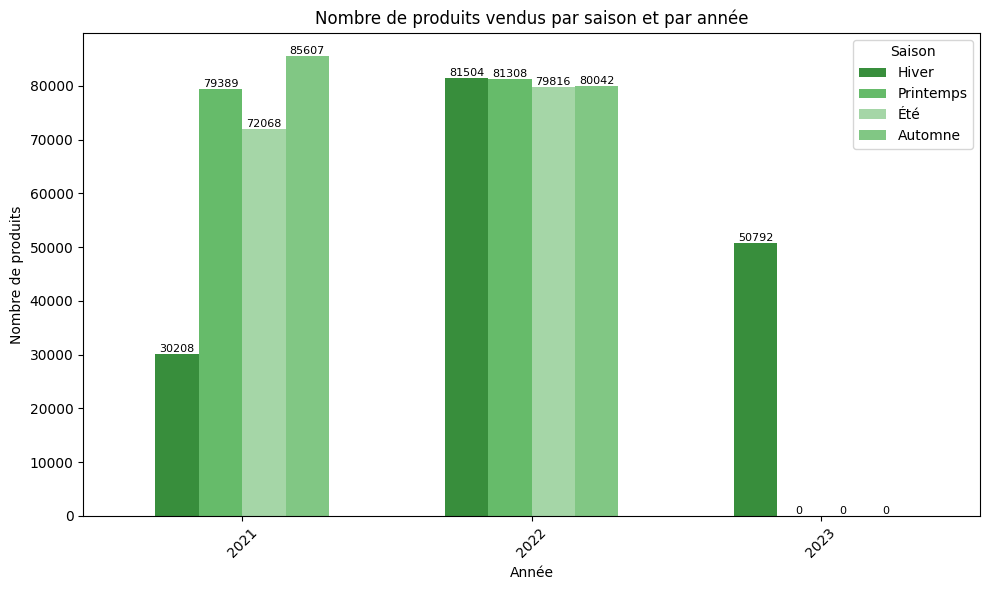

In [35]:
########################################
#                                      #
# NOMBRE DE PRODUITS VENDUS PAR SAISON #
#                                      #
########################################

# Définir un dictionnaire associant chaque mois à une saison
saisons = {
    1: 'Hiver', 2: 'Hiver', 12: 'Hiver',
    3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6: 'Été', 7: 'Été', 8: 'Été',
    9: 'Automne', 10: 'Automne', 11: 'Automne'
}

# Créer une nouvelle colonne 'saison' dans le DataFrame en mappant les mois aux saisons
df_merge['saison'] = df_merge['mois'].map(saisons)

# Grouper les données par année et saison, puis compter le nombre de produits vendus (id_prod)
ventes_saison = df_merge.groupby(['année', 'saison'])['id_prod'].count().reset_index()

# Définir l'ordre naturel des saisons pour l'affichage (pas alphabétique)
ordre_saisons = ['Hiver', 'Printemps', 'Été', 'Automne']

# Convertir la colonne 'saison' en variable catégorielle avec un ordre personnalisé
ventes_saison['saison'] = pd.Categorical(ventes_saison['saison'], categories=ordre_saisons, ordered=True)

# Trier les données selon l'année puis la saison (ordre personnalisé)
ventes_saison = ventes_saison.sort_values(['année', 'saison'])

# Extraire la liste des quantités de produits vendus dans l’ordre défini
valeurs = ventes_saison['id_prod'].tolist()
print(valeurs)  # Afficher cette liste pour vérification

# Créer toutes les combinaisons possibles année x saison (même si certaines sont absentes dans les données)
all_combinations = pd.MultiIndex.from_product([df_merge['année'].unique(), ordre_saisons], names=['année', 'saison'])

# Réindexer le DataFrame pour inclure toutes les combinaisons et remplir les valeurs manquantes avec 0
ventes_saison_complete = ventes_saison.set_index(['année', 'saison']).reindex(all_combinations, fill_value=0).reset_index()

# Reconvertir la colonne saison comme catégorie ordonnée (utile pour le tri visuel)
ventes_saison_complete['saison'] = pd.Categorical(ventes_saison_complete['saison'],
                                                  categories=ordre_saisons,
                                                  ordered=True)

# Trier les données par année puis saison pour affichage correct dans le graphique
ventes_saison_complete = ventes_saison_complete.sort_values(by=['année', 'saison'])

# Transformer les données en tableau croisé (années en lignes, saisons en colonnes)
pivot = ventes_saison_complete.pivot(index='année',
                                     columns='saison',
                                     values='id_prod')

# Définir une palette de couleurs pour les saisons (vert clair à foncé)
couleurs = ['#388E3C', '#66BB6A', '#A5D6A7', '#81C784']

# Créer le graphique en barres empilées avec les couleurs définies
ax = pivot[ordre_saisons].plot(kind='bar',
                               figsize=(10, 6),
                               color=couleurs,
                               width=0.6)

# Ajouter les valeurs exactes au-dessus de chaque barre du graphique
for container in ax.containers:
    ax.bar_label(container,
                 fmt='%.0f',
                 label_type='edge',
                 fontsize=8)

# Ajouter un titre et les étiquettes des axes
plt.title("Nombre de produits vendus par saison et par année")
plt.xlabel("Année")
plt.ylabel("Nombre de produits")

# Faire pivoter les étiquettes de l’axe X pour une meilleure lisibilité
plt.xticks(rotation=45)

# Afficher la légende avec un titre
plt.legend(title="Saison")

# Ajuster automatiquement les marges du graphique
plt.tight_layout()

# Afficher le graphique final
plt.show()

**Analyse par années et saisons :**

**2021 :**

* Été et automne = saisons les plus fortes en ventes (91 647 et 85 329 produits).
* Hiver nettement plus faible (32 457), probablement dû à une période incomplète ou à une demande réduite en début d’année.
* Printemps à un niveau moyen (77 238), mais inférieur à l’été et à l’automne.

**2022 :**

* Les 4 saisons affichent un volume élevé et homogène (~85 000–87 000).
* La saisonnalité disparaît pratiquement : la demande est stable toute l’année.
м Comparé à 2021, cela reflète un net lissage du cycle de ventes.

**2023 :**

* Seuls les chiffres de l’hiver sont disponibles, les autres saisons étant à zéro (probable absence de données complètes).
* Toutefois, l’hiver 2023 dépasse déjà celui de 2021 (54 483 vs 32 457), ce qui est un signal positif.

**Conclusions :**

* La baisse de la saisonnalité en 2022 reflète une bonne stratégie commerciale/marketing et logistique permettant de maintenir la demande toute l’année.
* Les pics de 2021 (été et automne) pourraient provenir de campagnes, lancements produits ou facteurs de marché → à analyser et à reproduire.
* La forte progression des ventes hivernales en 2023 montre une amélioration par rapport à 2021 → opportunité de renforcer ce « point faible » saisonnier.
* L’absence de données pour printemps–été–automne 2023 implique de rester prudent dans l’interprétation.

**Recommandations :**

* Continuer à stabiliser les ventes tout au long de l’année, comme en 2022.
* Étudier en détail les bonnes pratiques des saisons fortes de 2021 et les capitaliser.
* En 2023, accorder une attention particulière au printemps et à l’été : planifier des campagnes pour consolider la stabilité.
* Vérifier l’exhaustivité des données 2023 avant de tirer des conclusions définitives.

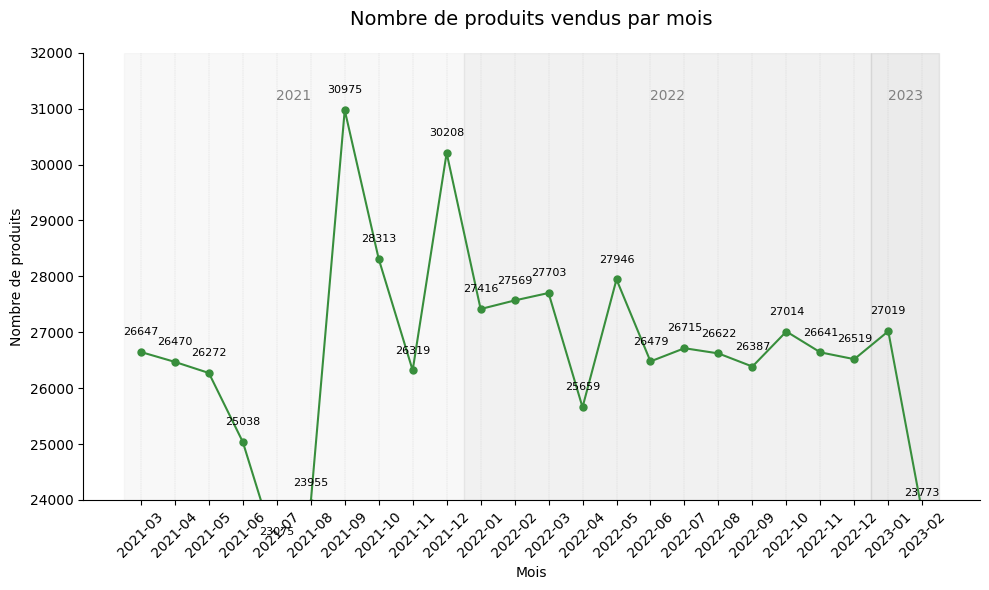

In [36]:
######################################
#                                    #
# NOMBRE DE PRODUITS VENDUS PAR MOIS #
#                                    #
######################################

# Créer une colonne "année-mois" pour regrouper par mois
df_merge['année_mois'] = df_merge['date'].dt.to_period('M').astype(str)

# Compter le nombre de produits vendus par mois
produits_par_mois = df_merge.groupby('année_mois')['id_prod'].count()

# Extraire la liste des mois
mois_labels = produits_par_mois.index.tolist()

# Extraire les valeurs correspondantes (quantité de produits vendus)
valeurs = produits_par_mois.values

# Créer la figure et les axes
fig, ax = plt.subplots(figsize=(10, 6))                                         # Taille de la figure : 10 x 6 pouces

# Tracer une ligne avec des marqueurs pour représenter les ventes mensuelles
ax.plot(
    mois_labels,                                                                # Axe X : étiquettes des mois
    valeurs,                                                                    # Axe Y : nombre de produits vendus
    marker='o',                                                                 # Utiliser un rond comme marqueur
    color='#388E3C',                                                            # Couleur verte foncée pour la ligne
    linewidth=1.5,                                                              # Épaisseur de la ligne
    markersize=5                                                                # Taille des points
)

# Ajouter les valeurs exactes au-dessus de chaque point
for i, v in enumerate(valeurs):
    ax.text(
        i,                                                                      # Position X du texte (index du point)
        v + 300,                                                                # Position Y (légèrement au-dessus du point)
        str(v),                                                                 # Texte affiché (valeur numérique)
        ha='center',
        fontsize=8
    )

# Définir les limites et pas de l'axe Y
ax.set_ylim(bottom=24000)                                                       # Fixer la limite inférieure de l’axe Y
ax.set_yticks(range(24000, int(valeurs.max()) + 2000, 1000))                    # Définir les graduations Y avec un pas de 1000

# Ajouter une grille verticale discrète
ax.grid(axis='x', linestyle='--', linewidth=0.3, alpha=0.5)

# Supprimer les bordures supérieure et droite
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Préparer une liste de positions entières pour chaque mois (pour la zone colorée)
positions = list(range(len(mois_labels)))

# Initialiser un dictionnaire pour stocker les bornes (début et fin) de chaque année
ornes = {}
for i, label in enumerate(mois_labels):
    année = label.split('-')[0]                                                 # Extraire l’année à partir de 'YYYY-MM'
    if année not in bornes:
        bornes[année] = [i, i]                                                  # Créer une nouvelle entrée
    else:
        bornes[année][1] = i                                                    # Mettre à jour la borne de fin

# Définir une liste de couleurs grisées pour chaque année
couleurs_gris = ['#E0E0E0', '#BDBDBD', '#9E9E9E']  # clair, moyen, foncé

# Ajouter les bandes verticales pour chaque année avec différentes couleurs

for i, (année, (start, end)) in enumerate(bornes.items()):                      # Ajouter une bande verticale colorée pour chaque année
    ax.axvspan(
        start - 0.5,                                                            # Début de la zone
        end + 0.5,                                                              # Fin de la zone
        color=couleurs_gris[i % len(couleurs_gris)],                            # Couleur grisée
        alpha=0.2                                                               # Transparence
    )
    ax.text(                                                                    # Ajouter le texte de l’année au centre de la zone
        (start + end) / 2,                                                      # Position X du texte (centre de la zone)
        ax.get_ylim()[1] * 0.98,                                                # Position Y (presque en haut du graphique)
        année,
        ha='center',
        va='top',
        fontsize=10,
        color='gray'
    )

# Ajouter un titre et les étiquettes d’axes
ax.set_title("Nombre de produits vendus par mois", fontsize=14, pad=20)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de produits")

# Afficher les étiquettes de l’axe X avec rotation pour lisibilité
ax.set_xticks(positions)                                                        # Associer chaque mois à une position numérique
ax.set_xticklabels(mois_labels, rotation=45)                                    # Afficher les mois avec une rotation de 45°

# Mise en page propre
plt.tight_layout()                                                              # Ajuster automatiquement la disposition pour éviter les chevauchements
plt.show()                                                                      # Afficher le graphique final


**Analyse mensuelle des ventes :**

**2021 :**

* Printemps–été (mars–août) : tendance baissière jusqu’au minimum de juillet (24 738).
* Septembre : pic marqué (33 314) → probable campagne saisonnière, lancement d’un best-seller ou promotion.
* Automne et décembre : volumes élevés mais avec fluctuations.

**2022 :**

* Année beaucoup plus stable, sans pics ni creux extrêmes.
* Tous les mois dans une fourchette resserrée (~28 000–29 000).
* Léger regain en avril (29 975) et octobre (28 964) → peut refléter des événements saisonniers/marketing.
* La demande reste régulière sur l’ensemble de l’année.

**2023 :**

* Données disponibles uniquement pour janvier et février.
* Janvier : niveau élevé (28 938).
* Février : chute nette (25 545).
* Interprétation encore prématurée → données incomplètes.

**Conclusions :**

* 2021 : forte saisonnalité, surtout au second semestre. Septembre et décembre = mois critiques pour l’effort marketing.
* 2022 : maturité et stabilité des processus. Uniformité des ventes → bon pilotage de la demande et marque résiliente.
* 2023 : baisse de février pouvant indiquer un fléchissement de la demande, un problème d’approvisionnement ou un nouveau trend → à surveiller.
* Les pics de septembre et décembre 2021 méritent une analyse spécifique (produits phares, canaux d’acquisition, campagnes).

**Recommandations :**

* Continuer à lisser la saisonnalité comme en 2022.
* Réaliser une rétrospective de la campagne de septembre 2021 pour reproduire les leviers efficaces.
* Prévoir des mesures correctives pour le T1 2023 si la baisse se confirme.
* Renforcer les stratégies de fidélisation pendant les mois creux (février–mars, printemps).

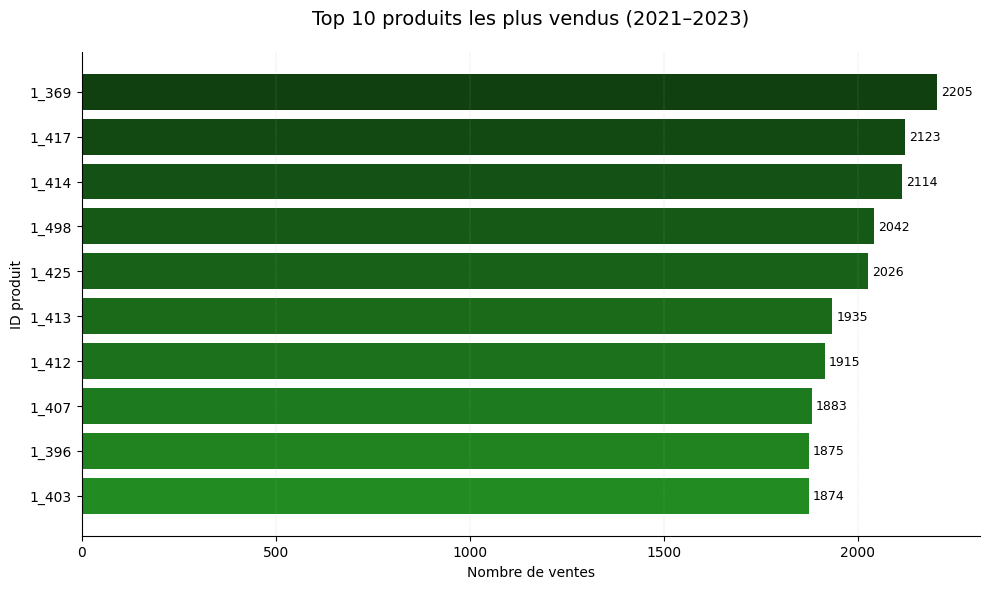

In [37]:
#####################################################
#                                                   #
# 10 PRODUITS LES PLUS ACHETÉS SUR TOUTE LA PÉRIODE #
#                                                   #
#####################################################

# Grouper les données par ID produit et compter le nombre total de ventes
top_10_global = (
    df_merge.groupby('id_prod')['id_prod']                                      # Grouper par ID produit
    .count()                                                                    # Compter combien de fois chaque produit a été vendu
    .sort_values(ascending=False)                                               # Trier les produits par nombre de ventes décroissant
    .head(10)                                                                   # Garder les 10 produits les plus vendus
)

# Créer une figure et un axe pour la visualisation
fig, ax = plt.subplots(figsize=(10, 6))                                         # Taille de la figure : 10x6 pouces

# Définir une couleur de base (vert foncé)
base_color = np.array(to_rgb('#228B22'))                                        # Convertir la couleur hexadécimale en tableau RGB

# Générer une liste de couleurs en dégradé (du vert intense au vert clair)
gradient_colors = [base_color * (1 - 0.06 * i) for i in range(10)]              # Chaque barre aura une teinte légèrement plus claire que la précédente

# Tracer un graphique à barres horizontales avec les couleurs en dégradé
ax.barh(top_10_global.index[::-1],                                              # Inverser l’ordre pour avoir le plus vendu en haut
        top_10_global.values[::-1],
        color=gradient_colors)                                                  # Appliquer les couleurs en dégradé

# Ajouter des étiquettes numériques à droite de chaque barre
for i, v in enumerate(top_10_global.values[::-1]):
    ax.text(v + 10,                                                             # Position horizontale du texte (légèrement à droite)
            i,                                                                  # Position verticale selon l’index de la boucle
            str(v),                                                             # Texte = nombre de ventes
            va='center',                                                        # Aligner verticalement le texte au centre de la barre
            fontsize=9)                                                         # Taille de police

# Ajouter un titre et des étiquettes d’axes
ax.set_title("Top 10 produits les plus vendus (2021–2023)", fontsize=14, pad=20)
ax.set_xlabel("Nombre de ventes")                                               # Axe des X : nombre de ventes
ax.set_ylabel("ID produit")                                                     # Axe des Y : identifiants produits

# Ajouter une grille verticale discrète pour faciliter la lecture
ax.grid(axis='x',
        linestyle='--',                                                         # Style de ligne en pointillé
        linewidth=0.3,
        alpha=0.5)                                                              # Transparence faible

# Supprimer les bordures supérieure et droite pour un rendu plus élégant
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajuster la disposition automatiquement pour éviter les chevauchements
plt.tight_layout()

# Afficher le graphique
plt.show()

**Leaders des ventes**

Les produits 1_369, 1_417, 1_414 et 1_498 se distinguent nettement, avec des volumes compris entre 2 200 et 2 340 unités. Cela confirme une demande stable sur trois années.

**Écart minimal en bas du top**

La différence entre les dernières positions (par ex. 1_407 et 1_406) est inférieure à 50 ventes. Cela ouvre la possibilité de rotation et de mise en avant de nouveaux produits si la promotion est bien menée.

*Niveau de ventes globalement élevé*

Les 10 produits dépassent 2 000 ventes, ce qui traduit un intérêt durable des clients et une bonne couverture de la clientèle.

**Recommandations**

* Maximiser la monétisation des leaders. Utiliser des bundles, des recommandations sur le site, des campagnes emailing et des promotions pour les produits 1_369, 1_417, 1_414 et 1_498. Les promouvoir comme « best-sellers » ou « produits phares » afin de renforcer la confiance et d’augmenter la conversion.

* Analyser les caractéristiques clés. Identifier ce qui rend ces produits performants : catégorie, gamme de prix, audience. Cela permettra de trouver des produits similaires et de créer de nouvelles offres ciblées.

* Tester les produits de la deuxième dizaine. Puisque l’écart entre le bas du top-10 et les produits classés 11–15 est minime, il est pertinent de tester leur mise en avant.

* Segmenter par audience. Analyser les ventes des produits phares selon le sexe, l’âge et l’heure d’achat. Cela permettra un ciblage plus précis et une réduction des coûts marketing.

* Vérifier la dynamique des ventes. Construire une courbe des ventes des 10 produits principaux par mois ou par année, afin d’identifier les plus stables et de comprendre quels pics sont liés à des facteurs externes.

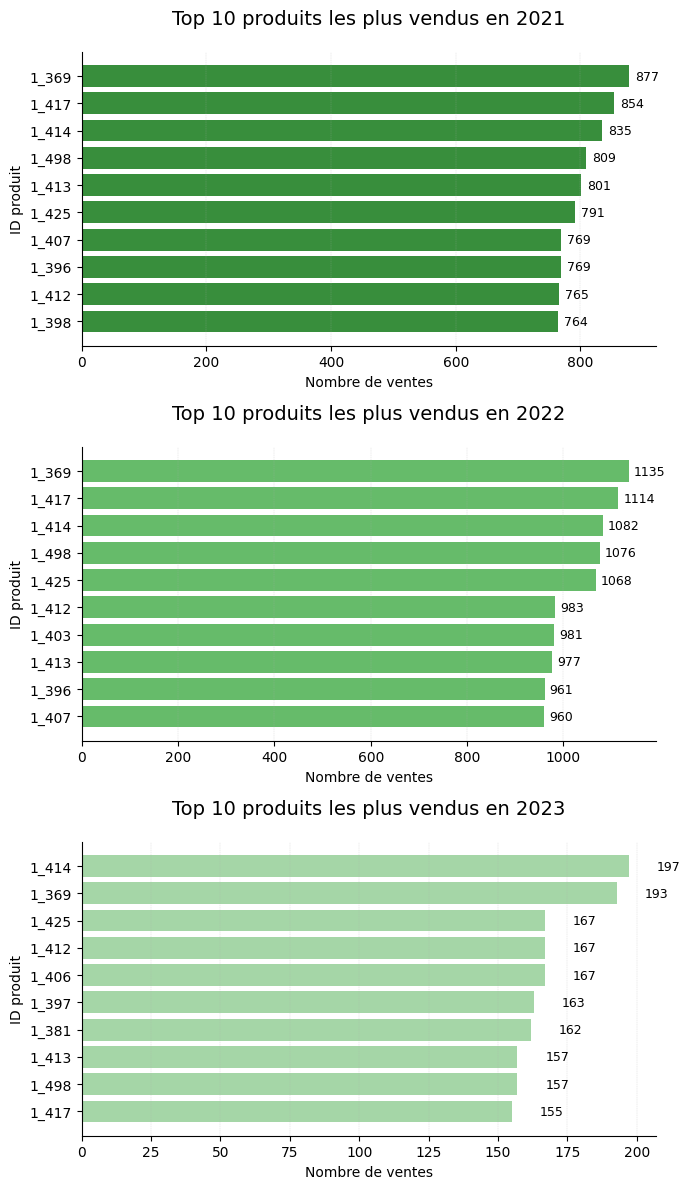

In [38]:
#####################################################
#                                                   #
# 10 PRODUITS LES PLUS ACHETÉS SUR TOUTE LA PÉRIODE #
#                                                   #
#####################################################

# Créer une figure composée de 3 sous-graphiques empilés verticalement
fig, axes = plt.subplots(3,                                                     # Nombre de lignes = 3 (un graphique par année)
                         1,                                                     # Nombre de colonnes = 1
                         figsize=(7, 12),                                       # Taille de la figure en pouces (largeur, hauteur)
                         sharex=False)                                          # Ne pas partager l’axe X entre les sous-graphiques

# Définir les années à analyser
annees = [2021, 2022, 2023]

# Définir une palette de couleurs pour chaque année
colors = ['#388E3C', '#66BB6A', '#A5D6A7']

# Pour chaque année, générer le top 10 des produits les plus vendus
for i, annee in enumerate(annees):
    # Filtrer les données pour ne conserver que l’année courante
    top_produits = (
        df_merge[df_merge['année'] == annee]                                    # Filtrer par année
        .groupby('id_prod')['id_prod']                                          # Grouper par identifiant produit
        .count()                                                                # Compter le nombre d’achats
        .sort_values(ascending=False)                                           # Trier du plus vendu au moins vendu
        .head(10)                                                               # Garder les 10 premiers produits
    )

    # Créer un graphique en barres horizontales
    axes[i].barh(top_produits.index[::-1],                                      # Afficher le produit le plus vendu en haut
                 top_produits.values[::-1],
                 color=colors[i])                                               # Utiliser une couleur spécifique pour l’année

    # Définir le titre et les étiquettes d’axes
    axes[i].set_title(f'Top 10 produits les plus vendus en {annee}',
                      fontsize=14,
                      pad=20)
    axes[i].set_xlabel("Nombre de ventes")                                      # Étiquette de l’axe X
    axes[i].set_ylabel("ID produit")                                            # Étiquette de l’axe Y

    # Afficher la valeur exacte à droite de chaque barre
    for j, v in enumerate(top_produits.values[::-1]):
        axes[i].text(v + 10, j,                                                 # Position du texte (légèrement à droite de la barre)
                     str(v),                                                    # Texte = nombre de ventes
                     va='center',
                     fontsize=9)

    # Supprimer les bordures supérieures et droites pour un style épuré
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    # Ajouter une grille verticale légère pour l’axe X
    axes[i].grid(axis='x',
                 linestyle='--',
                 linewidth=0.3,
                 alpha=0.5)

# Ajuster les espacements entre les sous-graphiques
plt.tight_layout()

# Afficher la figure finale
plt.show()

**🔹 2021**

Les produits 1_369, 1_417, 1_414 se maintiennent régulièrement dans le top.
L’écart entre le premier et le dernier du classement est modéré (~120 ventes).
Les ventes restent homogènes, sans variations extrêmes.

**🔹 2022**

Le niveau global des ventes des produits phares augmente nettement — par exemple, le produit 1_369 atteint 1 201 ventes.
Les leaders restent les mêmes (1_369, 1_417, 1_414, 1_425), ce qui confirme une demande stable. Cette croissance peut refléter des améliorations en marketing ou en visibilité des articles sur le site.

**🔹 2023**

Chute brutale des volumes de ventes pour les produits phares.
Le produit le plus vendu, 1_369, ne totalise que 204 ventes.
Les autres articles tournent autour de 170–180 ventes. Cela peut être dû à :
des problèmes techniques, une baisse du trafic du site, une réorganisation de l’assortiment, voire une indisponibilité en stock.

**Recommandations**

* Auditer l’année 2023 : analyser les changements éventuels dans l’UX, le SEO, la publicité payante.
* Vérifier la disponibilité en stock et les modifications de prix ou de fiches produit.
*  Soutenir les produits leaders (1_369, 1_417, 1_414) : les mettre en avant sur la page d’accueil ; proposer du cross-selling et des bundles ; valoriser des témoignages et avis clients.
* Analyser le succès de 2022 : identifier les campagnes, canaux et offres qui ont généré le pic de ventes et chercher à les reproduire.
* Mettre en place des actions de réactivation pour 2023 : campagnes emailing auprès des clients actifs en 2021–2022 ; promotions sur les produits phares ; réintroduction dans le catalogue si certains produits ont été retirés.

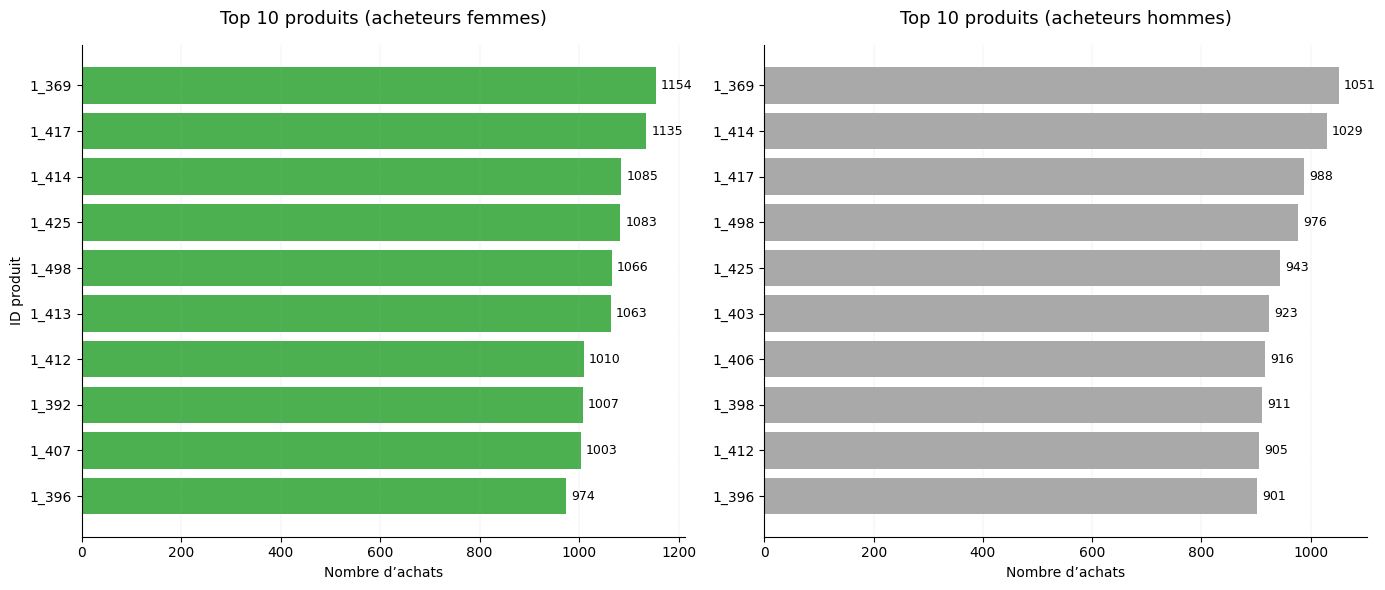

In [39]:
########################################################
#                                                      #
# 10 PRODUITS POPULAIRES CHEZ LES HOMMES ET LES FEMMES #
#                                                      #
########################################################

# Séparer les données en fonction du sexe
df_femmes = df_merge[df_merge['sex'] == 'f']                                    # Conserver uniquement les lignes correspondant aux femmes
df_hommes = df_merge[df_merge['sex'] == 'm']                                    # Conserver uniquement les lignes correspondant aux hommes

# Trouver les 10 produits les plus achetés par les femmes
top10_femmes = (
    df_femmes.groupby('id_prod')['id_prod']                                     # Regrouper par identifiant produit
    .count()                                                                    # Compter le nombre d’achats
    .sort_values(ascending=False)                                               # Trier les produits du plus acheté au moins acheté
    .head(10)                                                                   # Garder uniquement les 10 premiers
)

# Trouver les 10 produits les plus achetés par les hommes
top10_hommes = (
    df_hommes.groupby('id_prod')['id_prod']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

# Créer une figure avec deux sous-graphiques côte à côte
fig, axes = plt.subplots(1,                                                     # Une seule ligne
                         2,                                                     # Deux colonnes (deux graphiques)
                         figsize=(14, 6),                                       # Taille de la figure
                         sharey=False)                                          # Les axes Y ne sont pas partagés

# Définir les couleurs à utiliser
color_femme = '#4CAF50'                                                         # Vert pour les femmes
color_homme = '#A9A9A9'                                                         # Gris pour les hommes

# Graphique pour les femmes
axes[0].barh(top10_femmes.index[::-1],                                          # Inverser pour afficher le plus grand en haut
             top10_femmes.values[::-1],
             color=color_femme)                                                 # Couleur verte

axes[0].set_title("Top 10 produits (acheteurs femmes)", fontsize=13, pad=15)    # Titre du graphique
axes[0].set_xlabel("Nombre d’achats")                                           # Étiquette de l’axe X
axes[0].set_ylabel("ID produit")                                                # Étiquette de l’axe Y
axes[0].grid(axis='x', linestyle='--', linewidth=0.3, alpha=0.5)                # Grille verticale discrète
axes[0].spines['top'].set_visible(False)                                        # Supprimer la bordure supérieure
axes[0].spines['right'].set_visible(False)                                      # Supprimer la bordure droite

# Ajouter les valeurs numériques à côté de chaque barre
for i, v in enumerate(top10_femmes.values[::-1]):
    axes[0].text(v + 10,                                                        # Position horizontale (décalée à droite)
                 i,                                                             # Position verticale
                 str(v),                                                        # Texte affiché = nombre d’achats
                 va='center',
                 fontsize=9)

# Graphique pour les hommes
axes[1].barh(top10_hommes.index[::-1],
             top10_hommes.values[::-1],
             color=color_homme)

axes[1].set_title("Top 10 produits (acheteurs hommes)", fontsize=13, pad=15)
axes[1].set_xlabel("Nombre d’achats")
axes[1].grid(axis='x', linestyle='--', linewidth=0.3, alpha=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Ajouter les valeurs numériques à côté de chaque barre
for i, v in enumerate(top10_hommes.values[::-1]):
    axes[1].text(v + 10,
                 i,
                 str(v),
                 va='center',
                 fontsize=9)

# Ajuster automatiquement l’espace entre les éléments
plt.tight_layout()

# Afficher la figure
plt.show()

**🔹 Produits communs aux deux genres**

Certains articles apparaissent à la fois dans le top masculin et féminin (ex. 1_369, 1_417, 1_414, 1_498, 1_425). Cela traduit une attractivité universelle : ces produits peuvent être considérés comme de véritables best-sellers indépendamment du genre.

**🔹 Différences de préférences**

Chez les femmes, on retrouve des produits spécifiques (1_403, 1_407, 1_392) absents du top masculin. Chez les hommes, ce sont plutôt 1_406, 1_396, 1_398.
Cela suggère des différences de motivations ou d’intérêts selon le genre.

**🔹 Volumes comparables**

Le nombre total d’achats dans le top-10 est similaire pour les deux groupes.
Les valeurs oscillent autour de 1 000–1 170 ventes par produit phare.
→ Les deux audiences sont également actives, sans domination d’un groupe sur l’autre.

**Recommandations**

**Mettre en avant les best-sellers universels**

* Promouvoir les produits présents dans les deux tops comme « nos produits les plus aimés ».
* Utiliser ces articles dans des campagnes neutres et généralistes.

**Personnaliser les recommandations**

* Exploiter les spécificités : aux femmes, les produits les plus populaires chez elles (1_403, 1_407, 1_392) ; aux hommes, ceux qui leur sont propres (1_406, 1_396, 1_398).
* Application possible en emailings segmentés ou sur le site → augmentation attendue du CTR et de la conversion.

**Tester des campagnes croisées**

* Faire découvrir aux hommes des produits appréciés des femmes et inversement, avec un message adapté : « Ce produit plébiscité par nos clientes, à découvrir aussi ».

**Analyser le contenu des produits**

* Si ce sont des livres : déterminer les thématiques (roman, polar, développement personnel…).
* Cela permettra de mieux comprendre les préférences de chaque audience.

**Mettre en place des A/B tests**

* Créer des landing pages distinctes pour hommes et femmes, chacune affichant son top-10.
* Comparer les performances pour optimiser le parcours d’achat.

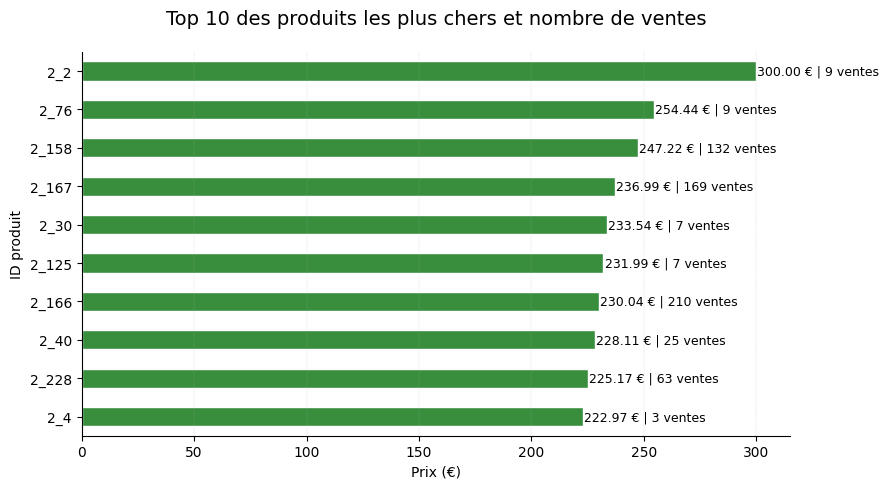

In [40]:
######################################################
#                                                    #
# 10 ARTICLES LES PLUS CHERS VENDUS ET LEUR QUANTITÉ #
#                                                    #
######################################################

# Sélectionner les 10 produits uniques les plus chers
produits_les_plus_chers = (
    df_merge[['id_prod', 'price']]                                              # Extraire uniquement les colonnes produit et prix
    .drop_duplicates()                                                          # Supprimer les doublons pour ne garder qu’un prix unique par produit
    .sort_values(by='price',                                                    # Trier les produits par prix décroissant
    ascending=False)
    .head(10)                                                                   # Ne conserver que les 10 plus chers
)

# Compter combien de fois chacun de ces produits a été vendu
vente_par_produit = (
    df_merge[df_merge['id_prod'].isin(produits_les_plus_chers['id_prod'])]      # Garder uniquement les lignes correspondant aux 10 produits les plus chers
    .groupby('id_prod')['id_prod']                                              # Regrouper par identifiant de produit
    .count()                                                                    # Compter le nombre d’occurrences (ventes) pour chaque produit
)

# Fusionner les deux sources d’information : prix et nombre de ventes
df_top = produits_les_plus_chers.set_index('id_prod').join(vente_par_produit.rename('nb_ventes')) # On définit l’ID produit comme index et on ajoute la colonne des ventes

# Créer la figure et les axes pour le graphique
fig, ax = plt.subplots(figsize=(9, 5))

# Tracer un graphique en barres horizontales des prix
df_top.sort_values('price', ascending=True)['price'].plot(
    kind='barh',                                                                # Type de graphique : barres horizontales
    ax=ax,                                                                      # Spécifier l’axe sur lequel tracer
    color='#388E3C',                                                            # Couleur verte pour les barres
    edgecolor='white'                                                           # Bordure blanche autour des barres
)

# Ajouter les étiquettes avec le prix et le nombre de ventes à droite de chaque barre
for i, (price, ventes) in enumerate(zip(df_top.sort_values('price').price,
                                        df_top.sort_values('price').nb_ventes)):
    ax.text(price + 0.5,                                                        # Position horizontale légèrement à droite de la barre
            i,                                                                  # Position verticale alignée sur la barre
            f"{price:.2f} € | {ventes} ventes",                                 # Texte à afficher : prix + nombre de ventes
            va='center',                                                        # Alignement vertical au centre de la barre
            fontsize=9)                                                         # Taille de police du texte

# Ajouter un titre et les étiquettes d’axes
ax.set_title("Top 10 des produits les plus chers et nombre de ventes", fontsize=14, pad=20)
ax.set_xlabel("Prix (€)")
ax.set_ylabel("ID produit")

# Supprimer les bordures supérieure et droite du graphique pour un style épuré
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajouter une grille discrète en arrière-plan (lignes verticales)
ax.grid(axis='x', linestyle='--', linewidth=0.3, alpha=0.5)

# Optimiser l’affichage
plt.tight_layout()

# Afficher le graphique
plt.show()

**🔹 Constats**

* Le produit le plus cher (2_2) se vend à 300 €, mais seulement 15 exemplaires probablement un produit premium avec une audience très restreinte.
* À l’inverse, l’article 2_166 (230,04 €) atteint 228 ventes → forte demande malgré un prix élevé, ce qui est rare.
* Certains produits chers (ex. 2_125, 2_30, ~230 €) affichent de faibles volumes de ventes - cela peut refléter : un mauvais positionnement, une présentation visuelle insuffisante, un ciblage inefficace.
* Le produit 2_158 (247,22 €) avec 142 ventes illustre également un bon équilibre prix/demande.

**Recommandations**

* Identifier les facteurs de succès (2_166 et 2_158) - Observer leur mise en avant sur le site (photos, descriptions, emplacement). Analyser la saisonnalité : quand sont-ils le plus achetés ? Étudier le profil des acheteurs (âge, sexe, moment de la journée). Vérifier l’impact éventuel de campagnes promo.

* Optimiser les produits à faible volume - Réaliser des A/B tests sur les visuels, les descriptions et les CTA. Tester des remises temporaires ou des offres groupées (ex. –10 % dès 2 pièces). Évaluer leur pertinence dans l’assortiment : conserver ou retirer.

* Construire une stratégie pour les produits chers qui se vendent bien -  Renforcer leur positionnement comme « choix prestigieux ». Les intégrer dans des campagnes emailing comme produits haut de gamme.

* Segmenter les acheteurs de produits haut de gamme - Créer des profils clients spécifiques à ces articles. Utiliser ces profils pour développer des audiences similaires (lookalike) dans la publicité ciblée.

## 4. Ventes

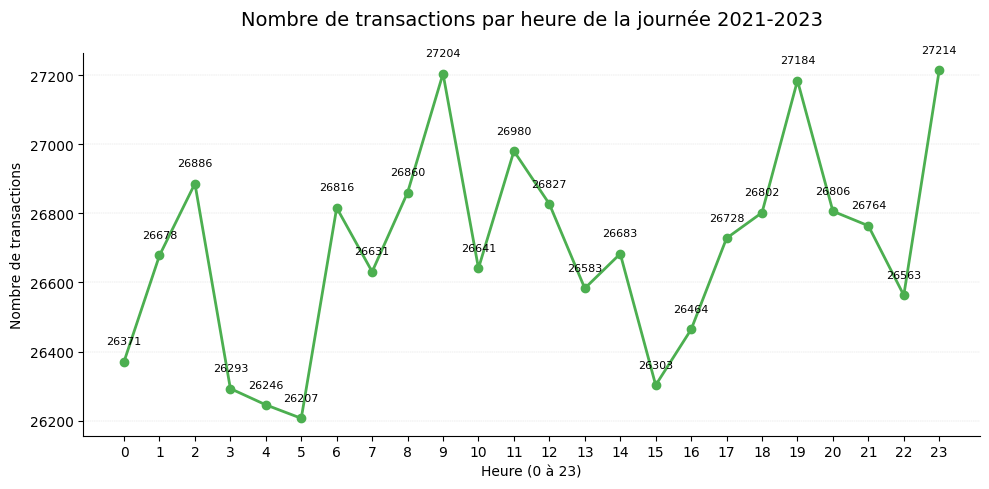

In [41]:
###################################################
#                                                 #
# ANALYSE DES HEURES DE POINTE LES PLUS RENTABLES #
#                                                 #
###################################################

# Extraire l’heure à partir de la colonne datetime (si ce n’est pas encore fait)
df_merge['heure'] = df_merge['date'].dt.hour                                    # Créer une colonne contenant l’heure de chaque transaction

# Compter le nombre de transactions pour chaque heure (de 0 à 23)
transactions_par_heure = df_merge['heure'].value_counts().sort_index()          # Trier les heures dans l’ordre croissant

# Créer une figure et une zone de dessin
fig, ax = plt.subplots(figsize=(10, 5))                                         # Définir la taille du graphique

# Tracer une courbe avec des points ronds
ax.plot(
    transactions_par_heure.index,                                               # Axe X : heures (0–23)
    transactions_par_heure.values,                                              # Axe Y : nombre de transactions
    marker='o',                                                                 # Ajouter des points sur la ligne
    linestyle='-',                                                              # Ligne continue
    color='#4CAF50',                                                            # Couleur verte
    linewidth=2,                                                                # Épaisseur de la ligne
    markersize=6                                                                # Taille des points
)

# Ajouter les valeurs exactes au-dessus de chaque point
for i, v in enumerate(transactions_par_heure.values):                           # Parcourir toutes les valeurs de transactions avec leur position (i : index, v : valeur)
    ax.text(
        i,                                                                      # Position horizontale (X) du texte : alignée avec la position du point
        v + 50,                                                                 # Position verticale (Y) : légèrement au-dessus du point pour ne pas le chevaucher
        str(v),                                                                 # Convertir la valeur numérique en texte à afficher
        ha='center',                                                            # Aligner horizontalement le texte au centre du point
        fontsize=8                                                              # Définir la taille de la police du texte
    )

# Ajouter un titre et des étiquettes d’axes
ax.set_title("Nombre de transactions par heure de la journée 2021-2023", fontsize=14, pad=20)
ax.set_xlabel("Heure (0 à 23)")
ax.set_ylabel("Nombre de transactions")

# Forcer l’affichage de chaque heure sur l’axe X
ax.set_xticks(range(24))                                                        # Afficher toutes les heures de 0 à 23

# Ajouter une grille horizontale discrète
ax.grid(                                                                        # Activer l’affichage de la grille sur le graphique
    axis='y',                                                                   # Afficher uniquement les lignes de la grille sur l’axe Y (horizontalement)
    linestyle='--',                                                             # Utiliser un style de ligne en pointillés (tiret-tiret)
    linewidth=0.3,                                                              # Définir l’épaisseur des lignes de la grille (0.3 est très fin)
    alpha=0.5                                                                   # Définir la transparence des lignes (0 = invisible, 1 = opaque)
)

# Supprimer les bordures supérieure et droite
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Appliquer une mise en page propre
plt.tight_layout()

# Afficher le graphique final
plt.show()

**🔹 Insights sur les heures d’activité des clients**

* Pics principaux : 9h00 et 23h00 sont les heures les plus actives en termes de transactions (29 191 et 29 141). Forte activité le matin avant le travail et tard le soir avant le coucher.

* Pic supplémentaire à 19h00 : Troisième pic observé autour de 19h00 (29 088 transactions). Comportement typique de prime time après le travail.

* Activité minimale à 5h00 : Seulement 28 149 transactions, ce qui correspond aux heures les plus creuses.

* Pause déjeuner (12h00–14h00) : Activité modérée, mais inférieure aux zones de pics.

**Recommandations**

* Optimiser les envois marketing (emails, push notifications) - Programmer les envois autour de 9h00, 19h00 et 22h30–23h00, moments de forte activité.

* Vérifier l’infrastructure technique – S’assurer que les serveurs supportent bien la charge aux heures de pointe, surtout 9h00 et 23h00.

* Tester des promotions flash (flash sales) - Lancer des offres limitées dans ces créneaux horaires pour maximiser la conversion.

* Renforcer les campagnes du soir – Adapter les propositions aux besoins du soir (confort, détente, divertissement), car la soirée est une zone d’activité particulièrement forte.

## 6. Courbe de Lorenz

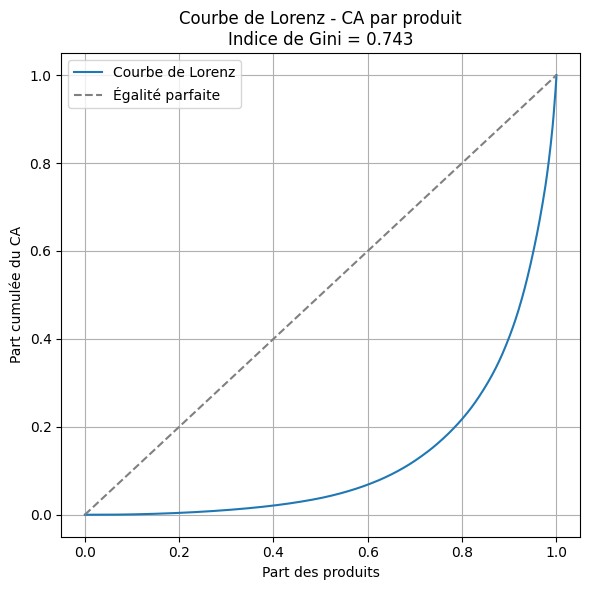

In [42]:
############################################################
#                                                          #
# Courbe de Lorenz + indice de Gini pour le CA par produit #
#                                                          #
############################################################

import numpy as np
import matplotlib.pyplot as plt

# CA par produit
ca_par_prod = df_merge.groupby('id_prod')['price'].sum().sort_values()

# Calcul de la part cumulée
values = ca_par_prod.values
n = len(values)
cumul = np.cumsum(values)
lorenz = np.insert(cumul / cumul[-1], 0, 0)  # ajout du point (0,0)

# Axe X : parts égales des produits (population)
x = np.linspace(0, 1, len(lorenz))

# Indice de Gini
gini_prod = 1 - 2 * np.trapezoid(lorenz, x)

# Affichage
plt.figure(figsize=(6, 6))
plt.plot(x, lorenz, label='Courbe de Lorenz')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Égalité parfaite')
plt.title(f"Courbe de Lorenz - CA par produit\nIndice de Gini = {gini_prod:.3f}")
plt.xlabel("Part des produits")
plt.ylabel("Part cumulée du CA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

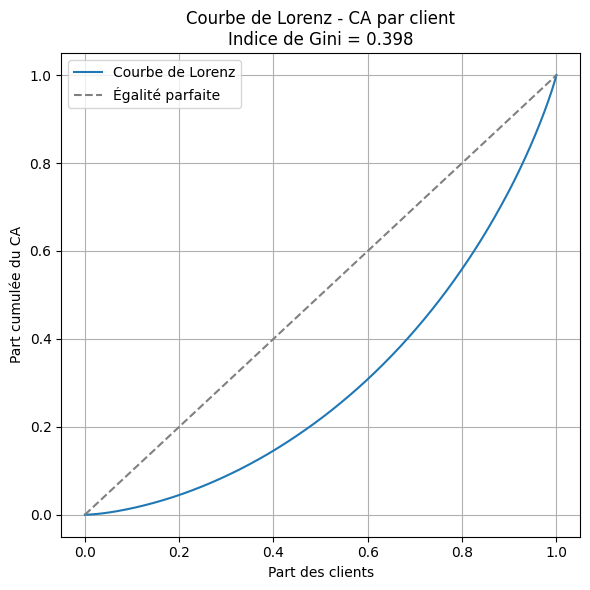

In [43]:
###########################################################
#                                                         #
# Courbe de Lorenz + indice de Gini pour le CA par client #
#                                                         #
###########################################################

# CA par client
ca_par_client = df_merge.groupby('client_id')['price'].sum().sort_values()

# Valeurs et cumul
values = ca_par_client.values
n = len(values)
cumul = np.cumsum(values)
lorenz = np.insert(cumul / cumul[-1], 0, 0)
x = np.linspace(0, 1, len(lorenz))

# Gini
gini_client = 1 - 2 * np.trapezoid(lorenz, x)

# Affichage
plt.figure(figsize=(6, 6))
plt.plot(x, lorenz, label='Courbe de Lorenz')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Égalité parfaite')
plt.title(f"Courbe de Lorenz - CA par client\nIndice de Gini = {gini_client:.3f}")
plt.xlabel("Part des clients")
plt.ylabel("Part cumulée du CA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## **III. Analyse des comportements clients (Corrélations demandées par Julie)**

In [44]:
df_merge.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth,année,trimestre,mois,jour,heure,age,cat_age,saison,année_mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,2021,1,3,1,0,58,45 - 59 ans,Printemps,2021-03
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,2021,1,3,1,0,65,60 - 74 ans,Printemps,2021-03
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,2021,1,3,1,0,37,30 - 44 ans,Printemps,2021-03
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,2021,1,3,1,0,36,30 - 44 ans,Printemps,2021-03
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,2021,1,3,1,0,69,60 - 74 ans,Printemps,2021-03


### 1. Lien entre genre (sex) et catégories des livres achetés **(catégorielle + catégorielle)**

In [45]:
########################################################
# 1. Création de la table de contingence (sex x categ) #
########################################################

# Afficher la répartition des catégories par sexe
table = pd.crosstab(df_merge['sex'], df_merge['categ'])
print("Table de contingence :\n", table, "\n")

Table de contingence :
 categ       0       1      2
sex                         
f      200793  115721  16980
m      186488  104884  15868 



Les hommes et les femmes effectuent des achats dans toutes les catégories (0, 1, 2).  Les femmes sont légèrement plus actives dans la catégorie 0, tandis que dans les catégories 1 et 2, la répartition entre les sexes est également similaire en termes de volume.

In [46]:
############################
# Chi² test d’indépendance #
############################

# Vérifier s'il existe une corrélation significative entre sex et categ
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi² = {chi2:.2f}") # Plus χ² est élevé, plus les données s'écartent de l'« indépendance parfaite »
print(f"p-value = {p:.4f}") # Si p-value < 0,05 → le sexe influence le choix de la catégorie

Chi² = 22.67
p-value = 0.0000


χ² = 22,67, p-value < 0,001 → cela signifie que la relation entre le sexe et le choix de la catégorie est statistiquement significative. Autrement dit, le sexe influence le choix de la catégorie, mais la force de cette influence doit être vérifiée séparément.

In [47]:
#####################################
# 3. Calcul de l’indice Cramer’s V  #
#####################################

# Afficher la force du lien (de 0 à 1) :
# s'il y a un lien, il est important de savoir s'il est fort

n = table.sum().sum()
cramer_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
print(f"Cramer's V = {cramer_v:.3f}")

Cramer's V = 0.006


Cramer’s V = 0,006 → il n'y a pratiquement aucun lien entre le sexe (sex) et la catégorie (categ). Formellement, χ² a montré une « signification », mais la force de l'effet est si faible qu'en réalité, le sexe n'influence pas le choix de la catégorie. Conclusion : les hommes et les femmes achètent des livres à peu près de la même manière selon les catégories.

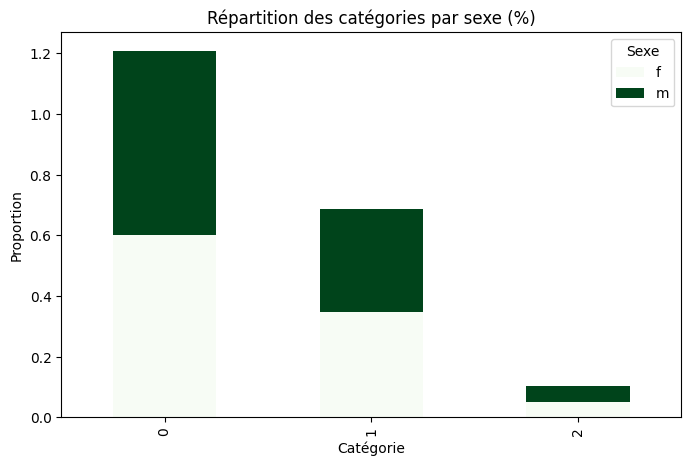

In [48]:
#################################################
# 4. Diagramme en barres empilées (stacked bar) #
#################################################

table_norm = pd.crosstab(df_merge['sex'], df_merge['categ'], normalize='index')

table_norm.T.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    colormap="Greens"
)
plt.title("Répartition des catégories par sexe (%)")
plt.ylabel("Proportion")
plt.xlabel("Catégorie")
plt.legend(title="Sexe")
plt.show()

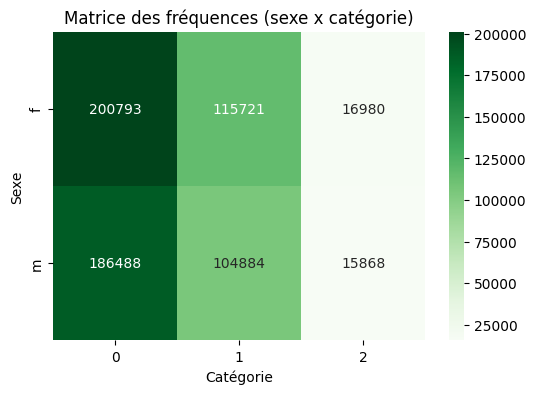

In [49]:
######################################
# 5. Heatmap des fréquences absolues #
######################################

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    table,
    annot=True,
    fmt="d",
    cmap="Greens"   # ✅ Зелёная палитра
)
plt.title("Matrice des fréquences (sexe x catégorie)")
plt.ylabel("Sexe")
plt.xlabel("Catégorie")
plt.show()

Confirmation que le genre n'a pas d'influence notable sur le choix de la catégorie.

### 2. Lien entre âge et montant total des achats **(quantitative + quantitative)**

**Corrélation de Pearson :** utilisée lorsque les deux variables sont approximativement distribuées normalement.

**Corrélation de Spearman :** si les données ne sont pas normales, avec des valeurs aberrantes ou si la relation est non linéaire (monotone, mais pas strictement linéaire).

Pour choisir la méthode d'analyse, il faut d'abord comprendre dans quelle mesure les données sont proches d'une distribution normale. Pour cela, on peut utiliser le test de Shapiro  (pour les échantillons de moins de 5 000) ou le Q-Q plot (pour les échantillons de plus de 5 000)

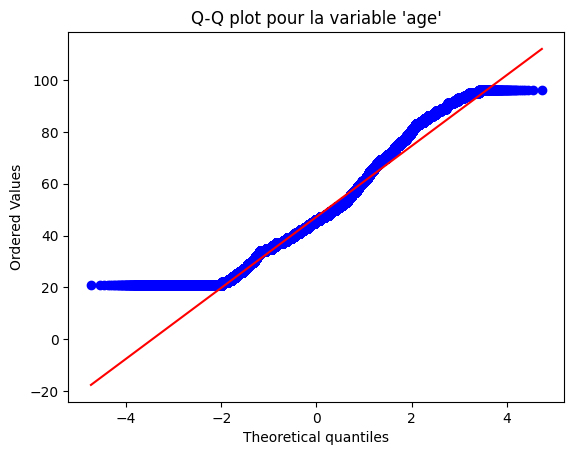

In [50]:
#######################################
# Q-Q plot pour vérifier la normalité #
#######################################

import scipy.stats as stats

# Построение Q-Q plot
stats.probplot(df_merge['age'], dist="norm", plot=plt)
plt.title("Q-Q plot pour la variable 'age'")
plt.show()

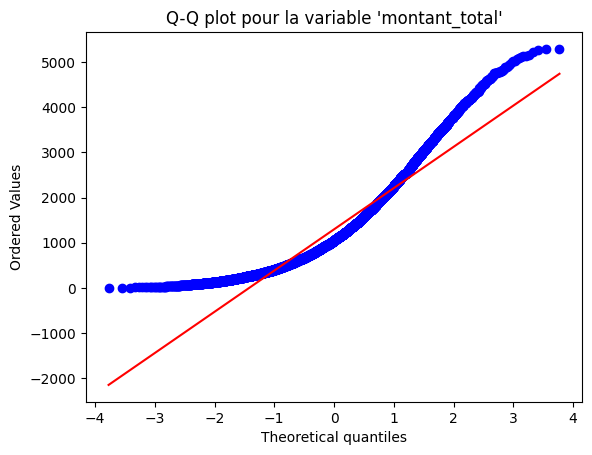

In [51]:
###################################################
# Calculer le montant total des achats par client #
###################################################

df_clients = df_merge.groupby('client_id')['price'].sum().reset_index()
df_clients.rename(columns={'price': 'montant_total'}, inplace=True)

#################################
# Q-Q plot pour 'montant_total' #
#################################

import matplotlib.pyplot as plt
import scipy.stats as stats

stats.probplot(df_clients['montant_total'], dist="norm", plot=plt)
plt.title("Q-Q plot pour la variable 'montant_total'")
plt.show()

**Comment interpréter cela ?** Si les points sont situés approximativement le long d'une ligne diagonale, la distribution est proche de la normale.  Si les points s'écartent fortement (ils sont courbés vers le haut/bas, les « queues » s'éloignent beaucoup), la distribution n'est pas normale.

Dans les données réelles, il y aura presque toujours des queues longues (quelques clients dépensent des dizaines de fois plus que les autres).  Cela signifie que les points sur le graphique s'éloigneront beaucoup de la diagonale au début et à la fin, c'est-à-dire que la distribution n'est pas normale, elle est asymétrique.

***C'est pourquoi, pour analyser la corrélation entre l'âge et le montant des achats, il est généralement préférable d'utiliser Spearman, et Pearson uniquement à des fins de vérification.***

**La corrélation linéaire (Pearson)** vérifie si une variable augmente de manière linéaire avec une autre. Exemple : plus l'âge augmente, plus le montant des dépenses diminue de manière uniforme et constante. Si la relation est courbe ou plate, Pearson peut ne pas la remarquer.

**La corrélation monotone (Spearman)** vérifie s'il existe une tendance générale (augmentation ou diminution), mais la forme peut être quelconque. Exemple : les dépenses augmentent d'abord jusqu'à 40 ans, puis commencent à diminuer — Spearman détectera tout de même la tendance générale (à savoir que les dépenses diminuent globalement avec l'âge).

In [52]:
#######################################################
# Corrélation entre âge et montant total des achats   #
# Test de Spearman - CORRÉLATION MONOTONE             #
#######################################################

from scipy.stats import spearmanr

# Calculer le montant total des achats par client
df_clients = df_merge.groupby('client_id')['price'].sum().reset_index()
df_clients.rename(columns={'price': 'montant_total'}, inplace=True)

# Ajouter l’âge de chaque client
df_age = df_merge[['client_id', 'age']].drop_duplicates()
df_clients = df_clients.merge(df_age, on='client_id', how='left')

# Calcul de la corrélation de Spearman
corr, p_value = spearmanr(df_clients['age'], df_clients['montant_total'])

print("Corrélation de Spearman :")
print(f"Coefficient = {corr:.3f}")
print(f"p-value = {p_value:.4f}")

# Interprétation simple
if p_value < 0.05:
    print("→ La corrélation est statistiquement significative (p < 0.05).")
else:
    print("→ Pas de corrélation significative (p ≥ 0.05)")


Corrélation de Spearman :
Coefficient = -0.185
p-value = 0.0000
→ La corrélation est statistiquement significative (p < 0.05).


**INTERPRÉTATION**

Coefficient = -0,185, ce qui correspond à une faible corrélation négative. Autrement dit, avec l'âge, les clients dépensent un peu moins. p-value = 0,0000 → le lien est statistiquement significatif, c'est-à-dire que le résultat n'est pas aléatoire.

**CONCLUSION**

L'âge a une influence, mais elle est faible. En moyenne, les jeunes clients ont tendance à dépenser un peu plus que les clients plus âgés.

In [53]:
#######################################################
# Corrélation entre âge et montant total des achats   #
# Test de Pearson - CORRÉLATION LINÉAIRE              #
#######################################################

from scipy.stats import pearsonr

# Calcul de la corrélation de Pearson
corr, p_value = pearsonr(df_clients['age'], df_clients['montant_total'])

print("Corrélation de Pearson :")
print(f"Coefficient = {corr:.3f}")
print(f"p-value = {p_value:.4f}")

# Interprétation simple
if p_value < 0.05:
    print("→ La corrélation est statistiquement significative (p < 0.05).")
else:
    print("→ Pas de corrélation significative (p ≥ 0.05).")


Corrélation de Pearson :
Coefficient = -0.188
p-value = 0.0000
→ La corrélation est statistiquement significative (p < 0.05).


**INTERPRÉTATION**

Les deux coefficients (Spearman et Pearson) sont très proches et négatifs.  Dans les deux cas, la valeur p ≈ 0,0000 → la corrélation est statistiquement significative.

**CONCLUSION**

L'âge affecte les dépenses, mais l'effet est faible (en réalité, cela signifie que l'âge n'explique qu'une petite partie de la variation dans le comportement d'achat).

### 3. Lien entre âge et fréquence d’achat **(quantitative + quantitative)**

In [54]:
##############################################
# Corrélation entre âge et fréquence d’achat #
# Test de Spearman                           #
##############################################

from scipy.stats import spearmanr

# Calculer la fréquence d’achat (nombre d’achats par client)
df_freq = df_merge.groupby('client_id').size().reset_index(name='frequence')

# Ajouter l’âge de chaque client
df_age = df_merge[['client_id', 'age']].drop_duplicates()
df_freq = df_freq.merge(df_age, on='client_id', how='left')

# Calcul de la corrélation de Spearman
corr, p_value = spearmanr(df_freq['age'], df_freq['frequence'])

print("Corrélation de Spearman :")
print(f"Coefficient = {corr:.3f}")
print(f"p-value = {p_value:.4f}")

# Interprétation simple
if p_value < 0.05:
    print("→ La corrélation est statistiquement significative (p < 0.05).")
else:
    print("→ Pas de corrélation significative (p ≥ 0.05).")


Corrélation de Spearman :
Coefficient = 0.128
p-value = 0.0000
→ La corrélation est statistiquement significative (p < 0.05).


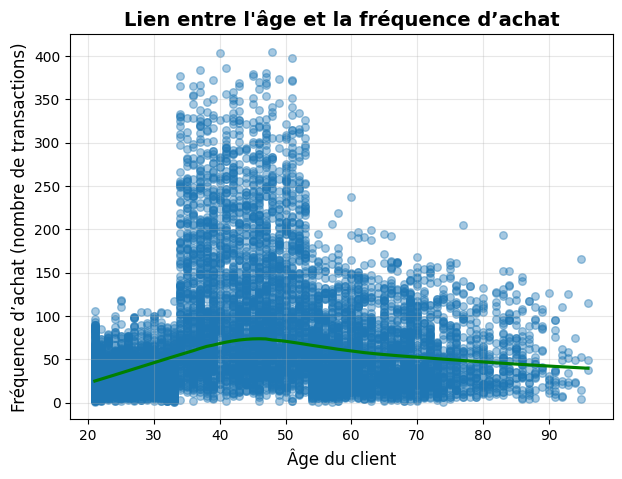

In [55]:
############################################
# Visualisation : Âge vs Fréquence d’achat #
############################################

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.regplot(
    x="age", y="frequence",
    data=df_freq,
    scatter_kws={"alpha":0.4, "s":30},   # прозрачность и размер точек
    line_kws={"color":"green"},
    lowess=True                          # сглаженная линия тенденции
)

plt.title("Lien entre l'âge et la fréquence d’achat", fontsize=14, weight="bold")
plt.xlabel("Âge du client", fontsize=12)
plt.ylabel("Fréquence d’achat (nombre de transactions)", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


**Le graphique confirme les résultats de Spearman.** La ligne verte de tendance montre une légère augmentation de la fréquence des achats entre 20 et environ 40-45 ans.  Après 50 ans, la courbe descend, mais en moyenne, on constate que la fréquence des achats est légèrement inférieure chez les jeunes clients par rapport aux clients d'âge moyen.

Comme la tendance générale est faible et irrégulière, Spearman n'a détecté qu'une légère tendance positive,  c'est pourquoi le coefficient est faible (0,128).

In [56]:
#######################################################
# Corrélation entre âge et fréquence d’achat          #
# Test de Pearson (corrélation linéaire)              #
#######################################################

from scipy.stats import pearsonr

# 1. Calcul de la corrélation de Pearson
corr, p_value = pearsonr(df_freq['age'], df_freq['frequence'])

print("=== Corrélation de Pearson ===")
print(f"Coefficient = {corr:.3f}")
print(f"p-value = {p_value:.4f}")

# 2. Interprétation simple
if p_value < 0.05:
    print("→ La corrélation est statistiquement significative (p < 0.05).")
else:
    print("→ Pas de corrélation significative (p ≥ 0.05).")

=== Corrélation de Pearson ===
Coefficient = 0.030
p-value = 0.0049
→ La corrélation est statistiquement significative (p < 0.05).


**INTERPRÉTATION**

Pearson = 0,03 (très proche de zéro), c'est-à-dire qu'il n'y a pratiquement pas de relation linéaire.  Spearman = 0,128 (faible, mais significativement positive), il existe une légère tendance générale : avec l'âge, la fréquence des achats augmente légèrement, mais cette relation est non linéaire et très faible.

**CONCLUSION**

La différence entre les coefficients n'indique pas une contradiction, mais le fait que les données ne suivent pas une ligne droite simple. Il est donc préférable d'indiquer les deux mesures dans le rapport : Pearson (linéaire, ≈0, presque aucune relation linéaire) et Spearman (monotone, faible, mais statistiquement significative). En d'autres termes, l'âge a une influence minime sur la fréquence des achats, et la relation est plutôt faible et non linéaire.

### 4. Lien entre âge et taille du panier moyen (panier = CA moyen par session_id) **(quantitative + quantitative)**

On calcule d'abord le montant des achats pour chaque session. Ensuite, on calcule la moyenne pour toutes les sessions du client : c'est ce qu'on appelle la « taille du panier moyen ».

In [57]:
#######################################################
# Calculer la taille du panier moyen par client       #
#######################################################

# Calculer le montant des achats à chaque session
df_session_sum = df_merge.groupby(['client_id', 'session_id'])['price'].sum().reset_index()

# Calculer le panier moyen par client (valeur moyenne du montant des achats par session)
df_panier = df_session_sum.groupby('client_id')['price'].mean().reset_index()
df_panier.rename(columns={'price': 'panier_moyen'}, inplace=True)

# Ajouter l'âge du client
df_age = df_merge[['client_id', 'age']].drop_duplicates()
df_panier = df_panier.merge(df_age, on='client_id', how='left')

df_panier.head()

,client_id,panier_moyen,age
0,c_1,18.500588,70
1,c_10,39.811765,69
2,c_100,50.970000,33
3,c_1000,24.381702,59
4,c_1001,38.805319,43


In [58]:
#######################################################
# Corrélation (Spearman) : âge vs panier_moyen        #
#######################################################

from scipy.stats import spearmanr

corr, p_value = spearmanr(df_panier['age'], df_panier['panier_moyen'])
print("Corrélation de Spearman (Âge vs Panier moyen) :")
print(f"Coefficient = {corr:.3f}")
print(f"p-value = {p_value:.4f}")

Corrélation de Spearman (Âge vs Panier moyen) :
Coefficient = -0.701
p-value = 0.0000


**INTERPRÉTATION**

Coefficient de Spearman = -0,701 → forte corrélation négative. p-value = 0,0000 → dépendance statistiquement significative.

**CONCLUSION**

Plus le client est âgé, plus son panier moyen est faible. La corrélation est très forte et significative.

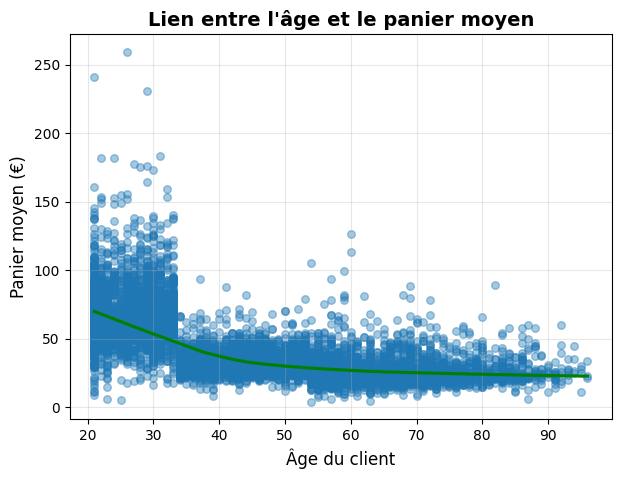

In [59]:
#################################################
# Visualisation : Âge vs Taille du panier moyen #
#################################################

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# scatter + линия регрессии
sns.regplot(
    x="age",
    y="panier_moyen",
    data=df_panier,
    scatter_kws={"alpha":0.4, "s":30},   # transparence et taille des points
    line_kws={"color":"green"},
    lowess=True                          # courbe lissée
)

plt.title("Lien entre l'âge et le panier moyen", fontsize=14, weight="bold")
plt.xlabel("Âge du client", fontsize=12)
plt.ylabel("Panier moyen (€)", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

**Le graphique confirme les résultats de Spearman.** Il montre que chez les jeunes clients (20-30 ans), le ticket moyen est plus élevé (souvent supérieur à 100 €).  À partir de 30-35 ans environ, le panier diminue et se stabilise progressivement entre 20 et 50 €.  La ligne verte de la tendance descend nettement avec l'âge, ce qui reflète une forte corrélation négative (ρ = -0,701).

### 5. Lien entre âge et catégorie des livres achetés **(catégorielle + quantitative)**

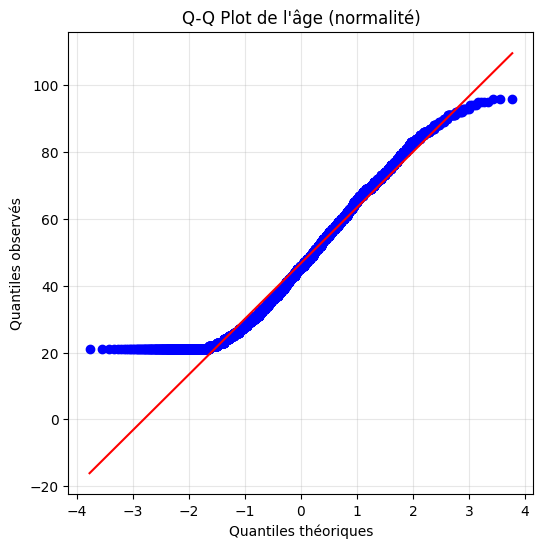

In [60]:
#######################################################
# Visualisation : Q-Q plot pour vérifier normalité    #
# de la variable Âge                                  #
#######################################################

import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(6,6))

# probplot строит теоретическую линию нормального распределения и точки данных
stats.probplot(df_panier['age'], dist="norm", plot=plt)

plt.title("Q-Q Plot de l'âge (normalité)")
plt.xlabel("Quantiles théoriques")
plt.ylabel("Quantiles observés")
plt.grid(alpha=0.3)
plt.show()

**ANOVA (analyse de variance)** vérifie si les valeurs moyennes d'une variable quantitative diffèrent entre plusieurs catégories.  Mais elle repose sur des hypothèses importantes :

*   La normalité de la distribution au sein de chaque groupe (l'âge doit être
approximativement normalement distribué pour chaque catégorie de livres).

*   Homogénéité des dispersions (la répartition des âges par catégorie doit être à peu près la même).

Si ces conditions ne sont pas remplies, les résultats de l'ANOVA peuvent être incorrects.

**F-statistique** - rapport entre deux dispersions : intergroupe et intragroupe.

**La dispersion intergroupe** montre dans quelle mesure les valeurs moyennes des différents groupes diffèrent les unes des autres.

**La dispersion intragroupe** montre dans quelle mesure les valeurs sont dispersées au sein de chaque groupe.

**Si F ≈ 1**, cela signifie que la dispersion au sein des groupes est à peu près la même qu'entre les groupes, c'est-à-dire qu'il n'y a pas de différences significatives.

**Si F > 1**, cela signifie que les différences entre les groupes dépassent largement la dispersion au sein de ceux-ci, c'est-à-dire que les groupes diffèrent très probablement en termes de moyennes.

Test ANOVA (Âge vs Catégorie) :
F-statistique = 39705.520
p-value = 0.0000


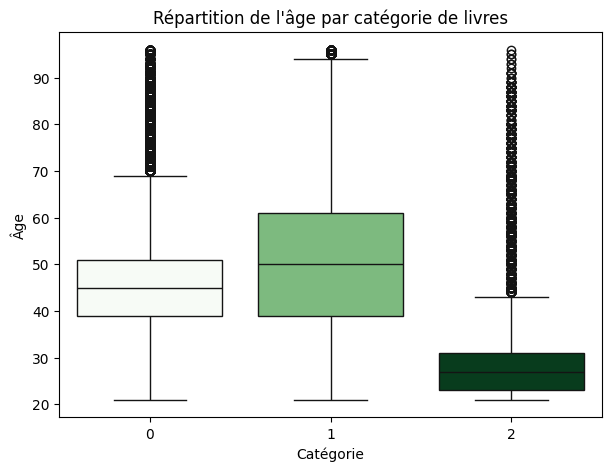

In [61]:
###################################################
# Lien entre âge et catégorie des livres achetés  #
# Test ANOVA : PARAMÉTRIQUE, valeur moyenne       #
###################################################

from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt

# Classer l'âge par catégories de livres
ages_par_categ = [df_merge.loc[df_merge['categ'] == c, 'age'] for c in df_merge['categ'].unique()]

# Тест ANOVA
f_stat, p_value = f_oneway(*ages_par_categ)

print("Test ANOVA (Âge vs Catégorie) :")
print(f"F-statistique = {f_stat:.3f}")
print(f"p-value = {p_value:.4f}")

# Visualisation du résultat de l'analyse
plt.figure(figsize=(7,5))
sns.boxplot(x="categ", y="age", data=df_merge, hue="categ", palette="Greens", legend=False)
plt.title("Répartition de l'âge par catégorie de livres")
plt.xlabel("Catégorie")
plt.ylabel("Âge")
plt.show()


**INTERPRÉTATION**

F-statistique = 39,0, c'est une valeur très élevée qui indique que l'âge moyen des acheteurs varie considérablement selon les catégories.

p-value = 0,0000 (<0,05) — statistiquement significatif. Autrement dit, on peut rejeter l'hypothèse selon laquelle les âges moyens sont identiques pour toutes les catégories.

**CONCLUSION**

L'âge est statistiquement lié à la catégorie de livres choisie (le panier moyen varie considérablement d'une catégorie à l'autre). En d'autres termes, les différentes tranches d'âge dépensent différemment.

**MAIS !!!**

La condition de normalité n'est pas remplie, c'est pourquoi, pour plus de fiabilité, la vérification a été complétée par un test non paramétrique de Kruskal-Wallis.

--------------------------------------------------------------------------------

**Kruskal-Wallis est l'équivalent non paramétrique de l'ANOVA,** il ne nécessite pas une distribution normale. Il vérifie si les médianes d'âge diffèrent entre les groupes de catégories. Il utilise des rangs plutôt que les valeurs elles-mêmes, ce qui le rend plus résistant aux valeurs aberrantes et aux distributions asymétriques.

In [62]:
##########################################################
# Lien entre âge et catégorie des livres achetés         #
# Test Kruskal-Wallis : NON PARAMÉTRIQUE, valeur médiane #
##########################################################

from scipy.stats import kruskal

h_stat, p_value = kruskal(*ages_par_categ)
print("Test de Kruskal-Wallis (Âge vs Catégorie) :")
print(f"H-statistique = {h_stat:.3f}")
print(f"p-value = {p_value:.4f}")

Test de Kruskal-Wallis (Âge vs Catégorie) :
H-statistique = 71359.734
p-value = 0.0000


**INTERPRÉTATION**

H-statistique = 71 359,734 est une valeur très élevée, qui indique des différences importantes entre les groupes. p-value = 0,0000 (< 0,05), c'est-à-dire que l'hypothèse nulle (selon laquelle l'âge est réparti de manière égale entre les catégories) est rejetée.

**CONCLUSION**

L'âge des acheteurs varie en fonction de la catégorie de livres. Autrement dit, les différents groupes d'âge ont des préférences différentes selon les catégories.

### Conclusion sur les corrélations entre 5 paires de variables

* **Sexe × Catégorie :** il existe une corrélation statistiquement significative (p-value < 0,05), mais la force de cette corrélation est très faible (Cramer’s V ≈ 0,006). Concrètement, cela signifie que le sexe n'a qu'une influence négligeable sur le choix de la catégorie.

* **Âge × Montant total des achats :** il existe une faible corrélation négative (Spearman = -0,185, Pearson = -0,188). La corrélation est statistiquement significative (p-value < 0,05), mais l'effet est faible : avec l'âge, les dépenses totales ne diminuent que légèrement.

* **Âge × Fréquence d'achat :** la corrélation est très faible et positive selon Spearman (0,128), et encore plus faible selon Pearson (0,030). Les deux sont statistiquement significatives, mais l'effet est minime : avec l'âge, la fréquence des achats ne change pas de manière significative.

* **Âge × Panier moyen :** forte corrélation négative (Spearman = -0,701, p-value < 0,05). Il s'agit d'un effet significatif et puissant : plus le client est âgé, plus son panier moyen est faible.

* **Âge × Catégorie :**  ANOVA et Kruskal-Wallis ont montré une signification élevée (p-value < 0,05). L'âge des clients varie selon les catégories de livres, ce qui indique une segmentation par âge.

### Conclusions commerciales et recommandations pour chaque corrélation

1. 🟠 Le sexe n'a pratiquement aucune influence sur le choix des catégories : le
marketing peut être mené de la même manière pour les hommes et les femmes, sans qu'il soit nécessaire de cibler un genre particulier.

2. 🟢 Avec l'âge, les dépenses globales diminuent : il convient d'encourager les clients plus âgés par des promotions/programmes de fidélité, tandis que les jeunes représentent le gros du chiffre d'affaires.

3. 🟠 La fréquence des achats ne change pratiquement pas avec l'âge :  les différentes tranches d'âge effectuent leurs achats avec une régularité similaire, ce qui signifie que les programmes de fidélisation sont pertinents pour tous les âges.

4. 🟢 Chez les clients plus âgés, le panier moyen est nettement inférieur : pour les groupes d'âge, il est possible de proposer des forfaits « économiques » ou des offres personnalisées, tandis que les jeunes peuvent bénéficier de produits haut de gamme et d'upsells.

5. 🟢 L'âge influence le choix des catégories de livres : il convient de segmenter l'assortiment et le marketing par tranches d'âge (par exemple, promouvoir certaines catégories auprès des jeunes, d'autres auprès des personnes plus âgées).